# Open Data Exploration: X-Maze Behavior and Spatial Firing

In this notebook, we will use an open NWB dataset from DANDI to explore behavior, spikes, and spatial firing. The dataset comes from Aery Jones et al. (2026), where mice ran an X-maze spatial match/non-match to position task while Neuropixels probes recorded from medial entorhinal cortex (MEC) and CA1.

https://www.nature.com/articles/s41593-026-02232-0

## 0. Setup

Run this once. In Colab, missing packages will be installed into the active runtime.

In [5]:
import importlib
import subprocess
import sys
from pathlib import Path

PACKAGE_IMPORTS = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "pillow": "PIL",
    "seaborn": "seaborn",
    "dandi": "dandi",
    "pynwb": "pynwb",
    "remfile": "remfile",
    "h5py": "h5py",
    "h5glance": "h5glance",
    "plotly": "plotly",
    "ipywidgets": "ipywidgets",
    "scipy": "scipy",
}

# In Colab, only this notebook file is available locally, so the companion
# helper module has to be fetched from GitHub before it can be imported.
if "google.colab" in sys.modules and not Path("tutorial_utils.py").exists():
    import urllib.request

    TUTORIAL_UTILS_URL = (
        "https://raw.githubusercontent.com/anirudh073/camp2026/main/"
        "tutorial_utils.py"
    )
    urllib.request.urlretrieve(TUTORIAL_UTILS_URL, "tutorial_utils.py")
    print("Downloaded tutorial_utils.py from GitHub.")

import importlib
import tutorial_utils

importlib.reload(tutorial_utils)

from tutorial_utils import (
    EXPECTED_NWB_PATHS,
    check_nwb_path,
    compute_occupancy_map,
    compute_rate_map,
    map_spikes_to_position_frames,
    get_unit_spike_times as fetch_unit_spike_times,
    smooth_rate_map,
    unit_region_from_row,
)


failed = {}
for package, import_name in PACKAGE_IMPORTS.items():
    try:
        importlib.import_module(import_name)
    except Exception as exc:
        failed[package] = repr(exc)

print(f"Python executable: {sys.executable}")
print(f"Python version: {sys.version.split()[0]}")

if failed:
    print("Installing missing packages into this notebook kernel:", list(failed))
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "--upgrade", *failed])
    print("Installed. If imports still fail, restart the runtime and rerun this cell.")
else:
    print("All required packages are available in this notebook kernel.")

Python executable: /Users/anirudh/miniforge3/envs/camp2026/bin/python
Python version: 3.11.15
All required packages are available in this notebook kernel.


## 1. Plotting Defaults

Use inline high-resolution plots and a modern color-blind-aware palette. The plotting context is set to `notebook`, which keeps figures readable without oversized text.

In [6]:
%config InlineBackend.figure_format = "retina" #high-resolution

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import ipywidgets as widgets

COLORS = {
    "blue": "#0072B2",
    "sky": "#56B4E9",
    "green": "#009E73",
    "orange": "#E69F00",
    "vermillion": "#D55E00",
    "purple": "#7A68A6",
    "pink": "#CC79A7",
    "gray": "#5F6368",
    "light_gray": "#D8DEE9",
    "dark": "#23272F",
}
PALETTE = [COLORS[k] for k in ["blue", "orange", "green", "pink", "sky", "vermillion", "purple", "gray"]]
RATE_MAP_CMAP = plt.get_cmap("afmhot").copy()
RATE_MAP_CMAP.set_bad(color="grey")

sns.set_theme(
    context="notebook",
    style="ticks",
    palette=PALETTE,
    rc={
        "figure.figsize": (7, 4.5),
        "figure.dpi": 180,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": False,
        "axes.titleweight": "bold",
        "axes.labelcolor": COLORS["dark"],
        "text.color": COLORS["dark"],
        "savefig.bbox": "tight",
    },
)
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=PALETTE)

## 2. Stream One NWB File From DANDI

We will start with one file from DANDI dataset `001701`. This dataset contains Neuropixels recordings from medial entorhinal cortex (MEC) and hippocampal area CA1. 

Paper context:

- Mice ran an X-maze with rewarded ports at arm ends.
- Days 1-10 used a match-to-sample rule.
- Days 11-20 used a nonmatch-to-sample rule.
- The paper asks how MEC represents task-relevant remote locations, especially during immobility.

In [7]:
from dandi.dandiapi import DandiAPIClient
import h5py
import remfile
from pynwb import NWBHDF5IO

DANDISET_ID = "001701"
DANDISET_VERSION = "0.260120.0303"

# Paper example session used for the CA1 spatial-firing examples.
asset_path = "sub-Lovelace/sub-Lovelace_ses-Lovelace-DY01-g1_behavior+ecephys.nwb"
# asset_path = "sub-Lamarr/sub-Lamarr_ses-Lamarr-DY01-g0_behavior+ecephys.nwb"

client = DandiAPIClient()
dandiset = client.get_dandiset(DANDISET_ID, DANDISET_VERSION)
asset = dandiset.get_asset_by_path(asset_path)

stream_url = asset.get_content_url(follow_redirects=1)
remote_file = remfile.File(stream_url)
h5_file = h5py.File(remote_file, mode="r")
io = NWBHDF5IO(file=h5_file, mode="r", load_namespaces=False)
nwb = io.read()

print("Streaming NWB file:")
print(asset_path)
print("\nSession description:", nwb.session_description)
print("Identifier:", nwb.identifier)

Streaming NWB file:
sub-Lovelace/sub-Lovelace_ses-Lovelace-DY01-g1_behavior+ecephys.nwb

Session description: X Maze
Identifier: AeryJones,EmilyLovelaceDY01-g1


## 3. Explore The NWB File Structure

NWB files are structured hierarchically. Before analyzing, find where the important data live.

**Activity: Use the browser below to find paths for position, units, and LFP.**

In [9]:
from h5glance import H5Glance

H5Glance(h5_file)

<remfile.RemFile.RemFile object at 0x131932650>/ (5 attributes)
├acquisition	(0 children)
├analysis	(0 children)
├file_create_date	[ASCII string: 1]
├general	(8 children)
├identifier	[UTF-8 string: scalar]
├processing	(3 children)
├session_description	[UTF-8 string: scalar]
├session_start_time	[ASCII string: scalar]
├specifications	(3 children)
├stimulus	(2 children)
├timestamps_reference_time	[ASCII string: scalar]
└units	(6 children) (5 attributes)

### Fill In The Paths

Use the browser above to fill these in before running the check cell.

| Data | Path |
| --- | --- |
| Position | `_____` |
| Units | `_____` |
| LFP | `_____` |

In [31]:
# Fill in the paths you found. These are strings, so keep the quotation marks.
paths = {
    "position": "processing/behavior/Position/position",
    "units": "units",
    "lfp": "processing/probe_0_channel_320/LFP",
}

for name, path in paths.items():
    status = "Correct!" if check_nwb_path(h5_file, path, **EXPECTED_NWB_PATHS[name]) else "Try again :("
    print(f"{name:15s} {status:12s} {path}")

position        Correct!     processing/behavior/Position/position
units           Correct!     units
lfp             Correct!     processing/probe_0_channel_320/LFP


The file browser shows where different objects live inside the NWB file. PyNWB is a Python library that reads NWB files and represents those objects as Python objects rather than raw HDF5 groups and datasets.

In the next cell, we use the paths you found to retrieve the position object and the units table from the streamed file. The small helper converts a path such as `processing/behavior/Position/position` into step-by-step access through the `nwb` object.


In [32]:
def get_by_hdf5_path(nwb_object, path):
    """Convert a simple HDF5-style path into chained NWB object access."""
    obj = nwb_object
    for part in path.split("/"):
        if not part:
            continue
        obj = obj[part] if hasattr(obj, "__getitem__") else getattr(obj, part)
    return obj

position_series = get_by_hdf5_path(nwb, paths["position"])
units = get_by_hdf5_path(nwb, paths["units"])

print("Position object:", position_series)
print("--------------")
print("\nNumber of units:", len(units))

Position object: position pynwb.behavior.SpatialSeries at 0x5135590800
Fields:
  comments: no comments
  conversion: 1.0
  data: <HDF5 dataset "data": shape (115820, 2), type "<f8">
  description: no description
  offset: 0.0
  rate: 60.0
  reference_frame: (0,0) is bottom left corner
  resolution: -1.0
  starting_time: 4.44163
  starting_time_unit: seconds
  unit: centimeters

--------------

Number of units: 415


## 4. Behavior


The position object stores the animal's tracked location over time.

In the next cell, we will:

- read the full position array from the NWB file,
- check how many samples and position dimensions it contains,
- reconstruct a time value for each sample using the sampling rate and start time,
- split the two position columns into `x` and `y`,
- put `time`, `x`, and `y` into a `DataFrame` so the data are easy to inspect and plot.

The idea is to examine position and time together: we want to know **when** an animal was at each x and y coordinate. 


In [33]:
position_data = position_series.data[:]  # fetch data from the position directory of the NWB file
sampling_rate = position_series.rate
series_start_time = position_series.starting_time

# Question: how do we reconstruct the time point for each position sample?
# Hint: sample 0 occurs at series_start_time, and samples are spaced 1 / sampling_rate seconds apart.
# Solved version:
raw_time = series_start_time + np.arange(position_data.shape[0]) / sampling_rate
raw_x = position_data[:, 0]
raw_y = position_data[:, 1]

# Some sessions contain missing tracking samples marked as NaN.
# Remove them once here, so downstream position plots and spatial maps use finite positions.
valid_position = np.isfinite(raw_time) & np.isfinite(raw_x) & np.isfinite(raw_y)
time = raw_time[valid_position]
x = raw_x[valid_position]
y = raw_y[valid_position]

position_df = pd.DataFrame({"time": time, "x": x, "y": y})

print("position_data.shape:", position_data.shape)
print("sampling_rate:", sampling_rate, "Hz")
print("valid position samples:", f"{valid_position.sum()} / {len(valid_position)}")
print("time range:", f"{time[0]:.2f} to {time[-1]:.2f} s")
display(position_df.head())

position_data.shape: (115820, 2)
sampling_rate: 60.0 Hz
valid position samples: 114205 / 115820
time range: 4.44 to 1934.76 s


,time,x,y
0,4.441630,11.166757,9.683618
1,4.458297,11.184705,9.658853
2,4.474963,11.201572,9.635774
3,4.491630,11.216518,9.615696
4,4.508297,11.229099,9.599299


In [34]:
print("unit:", position_series.unit)
print("reference_frame:", position_series.reference_frame)
print("x range:", position_df["x"].min(), position_df["x"].max())
print("y range:", position_df["y"].min(), position_df["y"].max())

unit: centimeters
reference_frame: (0,0) is bottom left corner
x range: 5.796082468105275 80.20890603289963
y range: 7.568744948333833 97.4042375934025


Now we plot the full x-y position trace.

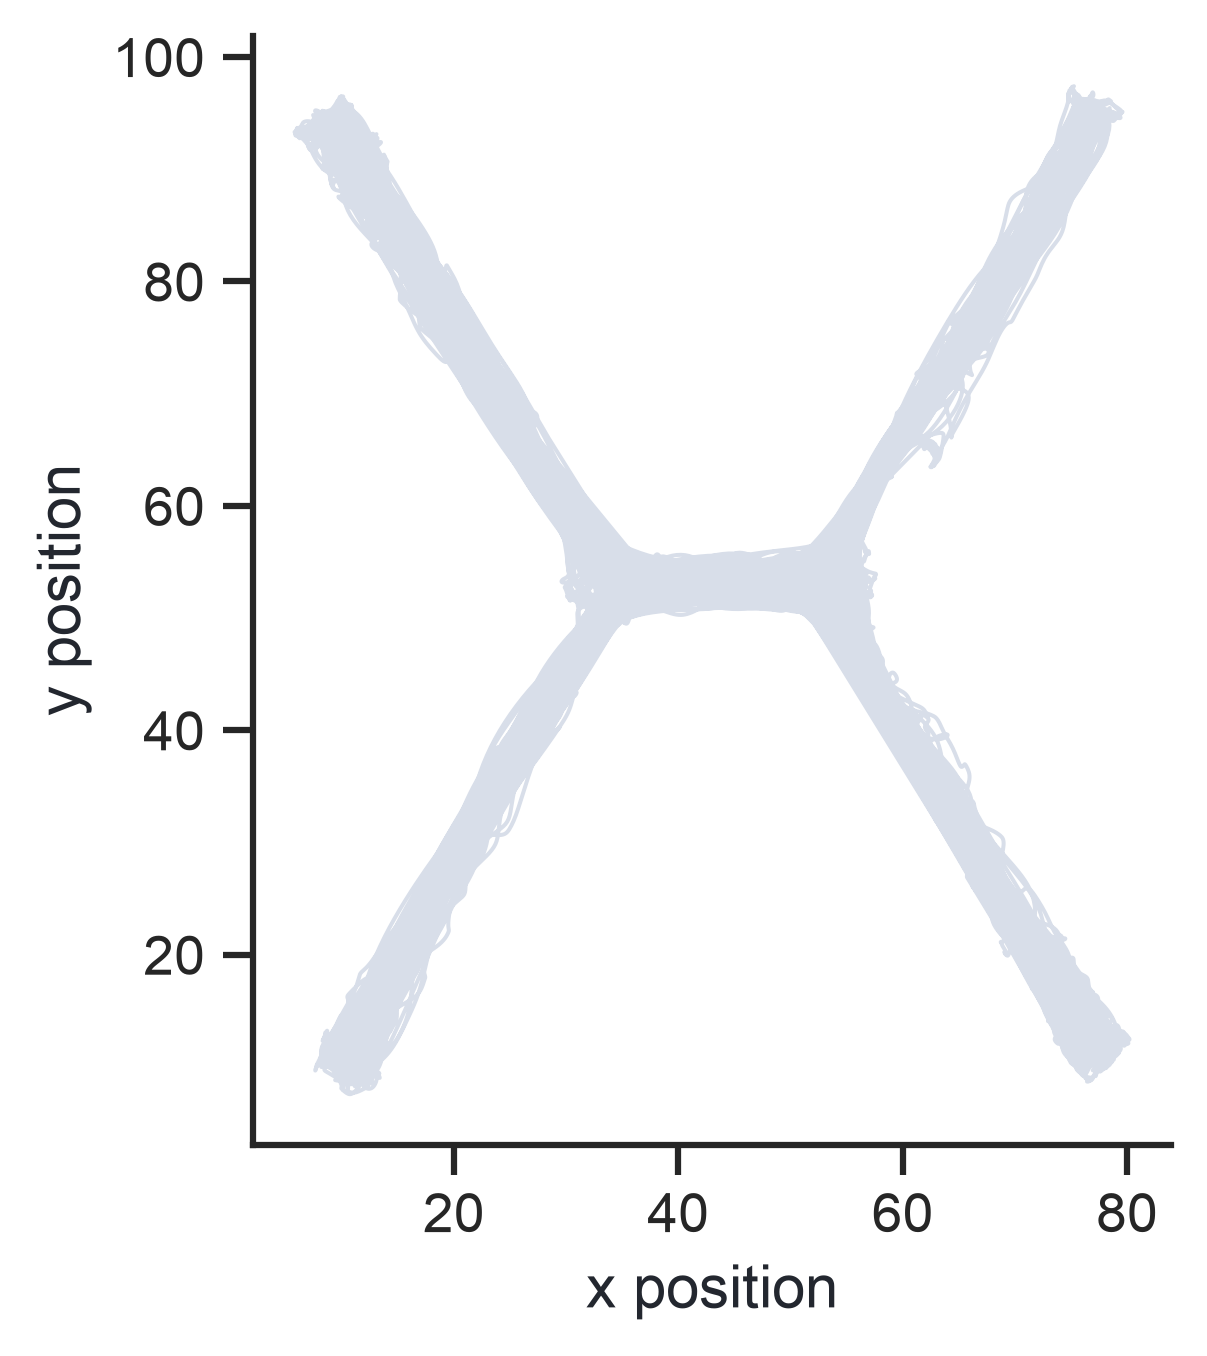

In [35]:
fig, ax = plt.subplots(figsize=(4, 4))
ax.plot(position_df["x"], position_df["y"], color=COLORS["light_gray"], linewidth=0.8)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("x position")
ax.set_ylabel("y position")
plt.show()

In [38]:
print("unit:", position_series.unit)
print("reference_frame:", position_series.reference_frame)
print("x range:", position_df["x"].min(), position_df["x"].max())
print("y range:", position_df["y"].min(), position_df["y"].max())

unit: centimeters
reference_frame: (0,0) is bottom left corner
x range: 5.796082468105275 80.20890603289963
y range: 7.568744948333833 97.4042375934025


Now, choose a short time window from the printed time range above and plot that segment on top of the full trajectory.

Selected 1788 samples from 90 to 120 seconds.


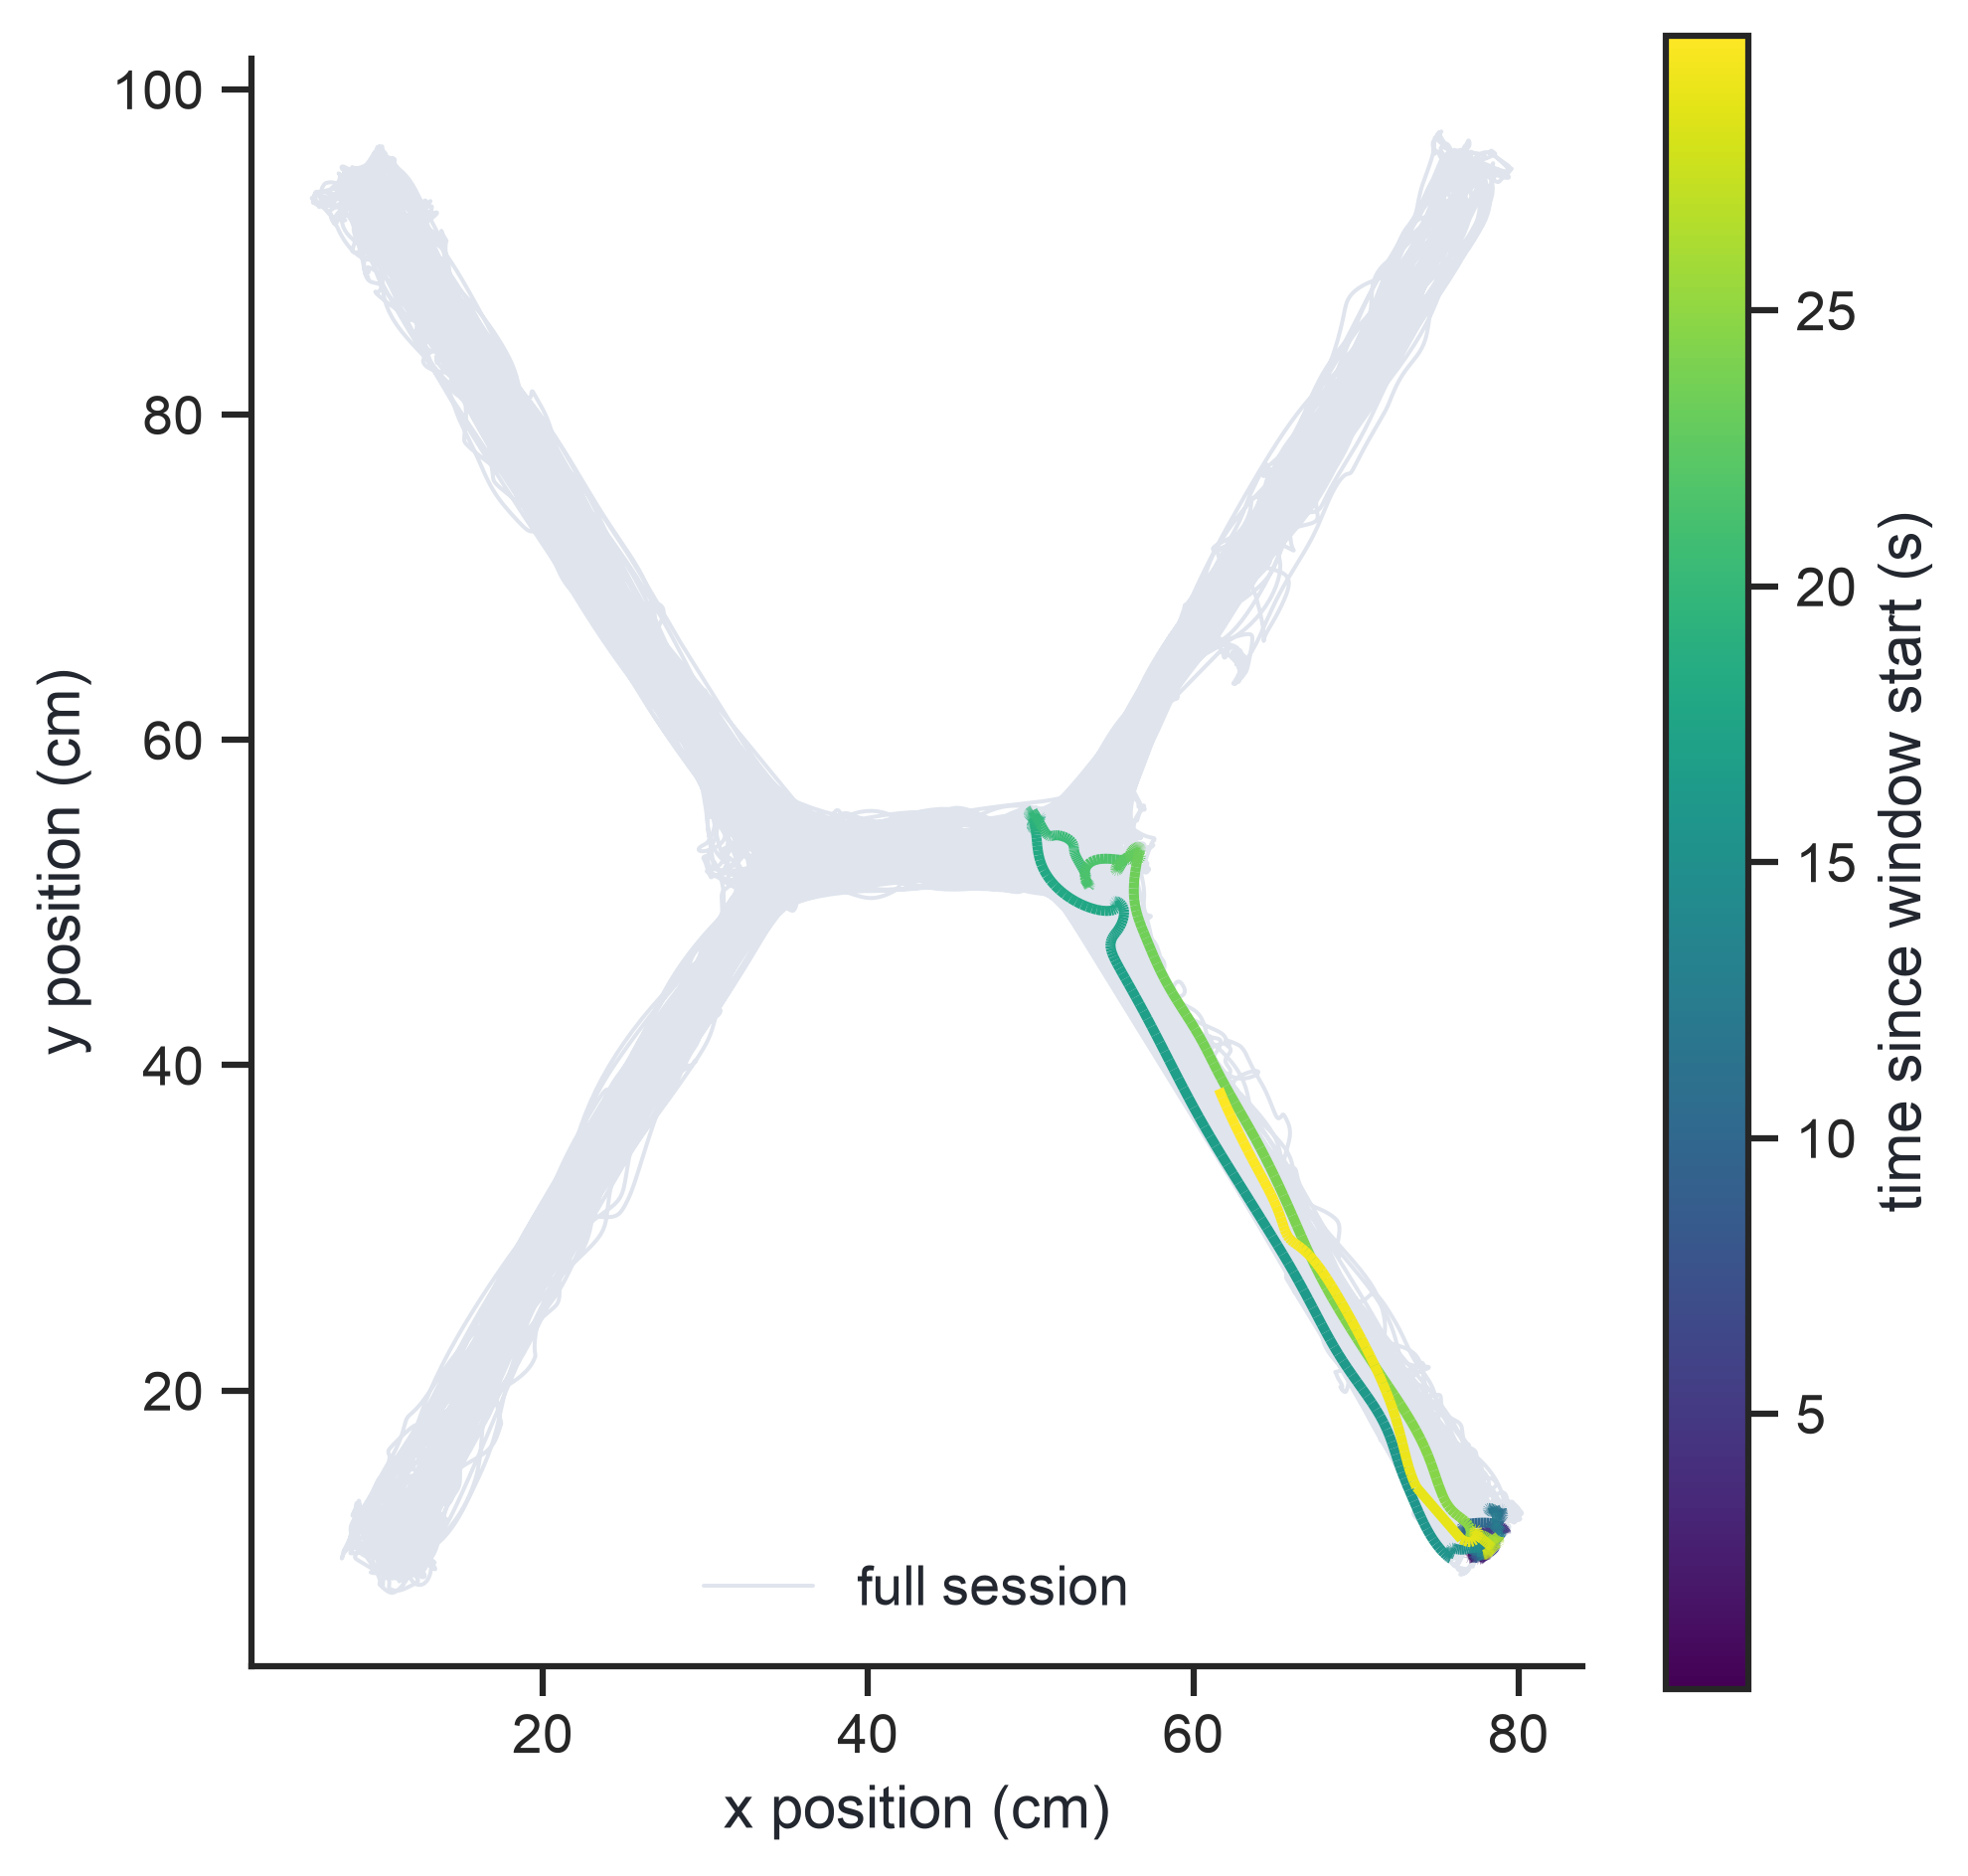

In [39]:
# Question: choose a short time window to inspect.
# Use the printed time range above, then edit these two values.
window_start = 90
window_stop = 120

window_df = position_df.query("@window_start <= time <= @window_stop")
if window_df.empty:
    raise ValueError("No position samples found in this window. Choose start and stop times within the printed time range.")

print(f"Selected {len(window_df)} samples from {window_start} to {window_stop} seconds.")

from matplotlib.collections import LineCollection

points = window_df[["x", "y"]].to_numpy().reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
segment_time = (window_df["time"].to_numpy()[:-1] + window_df["time"].to_numpy()[1:]) / 2 - window_start

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(position_df["x"], position_df["y"], color=COLORS["light_gray"], linewidth=0.8, alpha=0.8, label="full session")
time_trace = LineCollection(segments, cmap="viridis", linewidth=2.0, zorder=3)
time_trace.set_array(segment_time)
ax.add_collection(time_trace)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("x position (cm)")
ax.set_ylabel("y position (cm)")
plt.colorbar(time_trace, ax=ax, label="time since window start (s)")
ax.legend(frameon=False, loc="best")
plt.show()

## 5. Speed and Acceleration

Position gives us more than the shape of the maze. From x-y position over time, we can derive behavioral variables such as speed and acceleration.

These variables help us ask richer questions later, for example:

- does neural firing differ when the animal is moving versus stationary?

Speed is distance traveled per unit time:

```text
speed = distance / time
```

For x-y position, the distance between consecutive samples is:

```text
distance = sqrt(dx^2 + dy^2)
```

In [40]:
# Fill-in challenge: what should go into dx, dy, and dt?
dx = np.diff(x)
dy = np.diff(y)
dt = np.diff(time)

speed = np.sqrt(dx**2 + dy**2) / dt
speed_time = time[:-1] + dt / 2

speed_df = pd.DataFrame({"time": speed_time, "speed": speed})
display(speed_df.head())

,time,speed
0,4.449963,1.835111
1,4.466630,1.715113
2,4.483297,1.501799
3,4.499963,1.240059
4,4.516630,0.979140


Now plot speed over a time period.

Selected 1788 speed samples from 90 to 120 seconds.


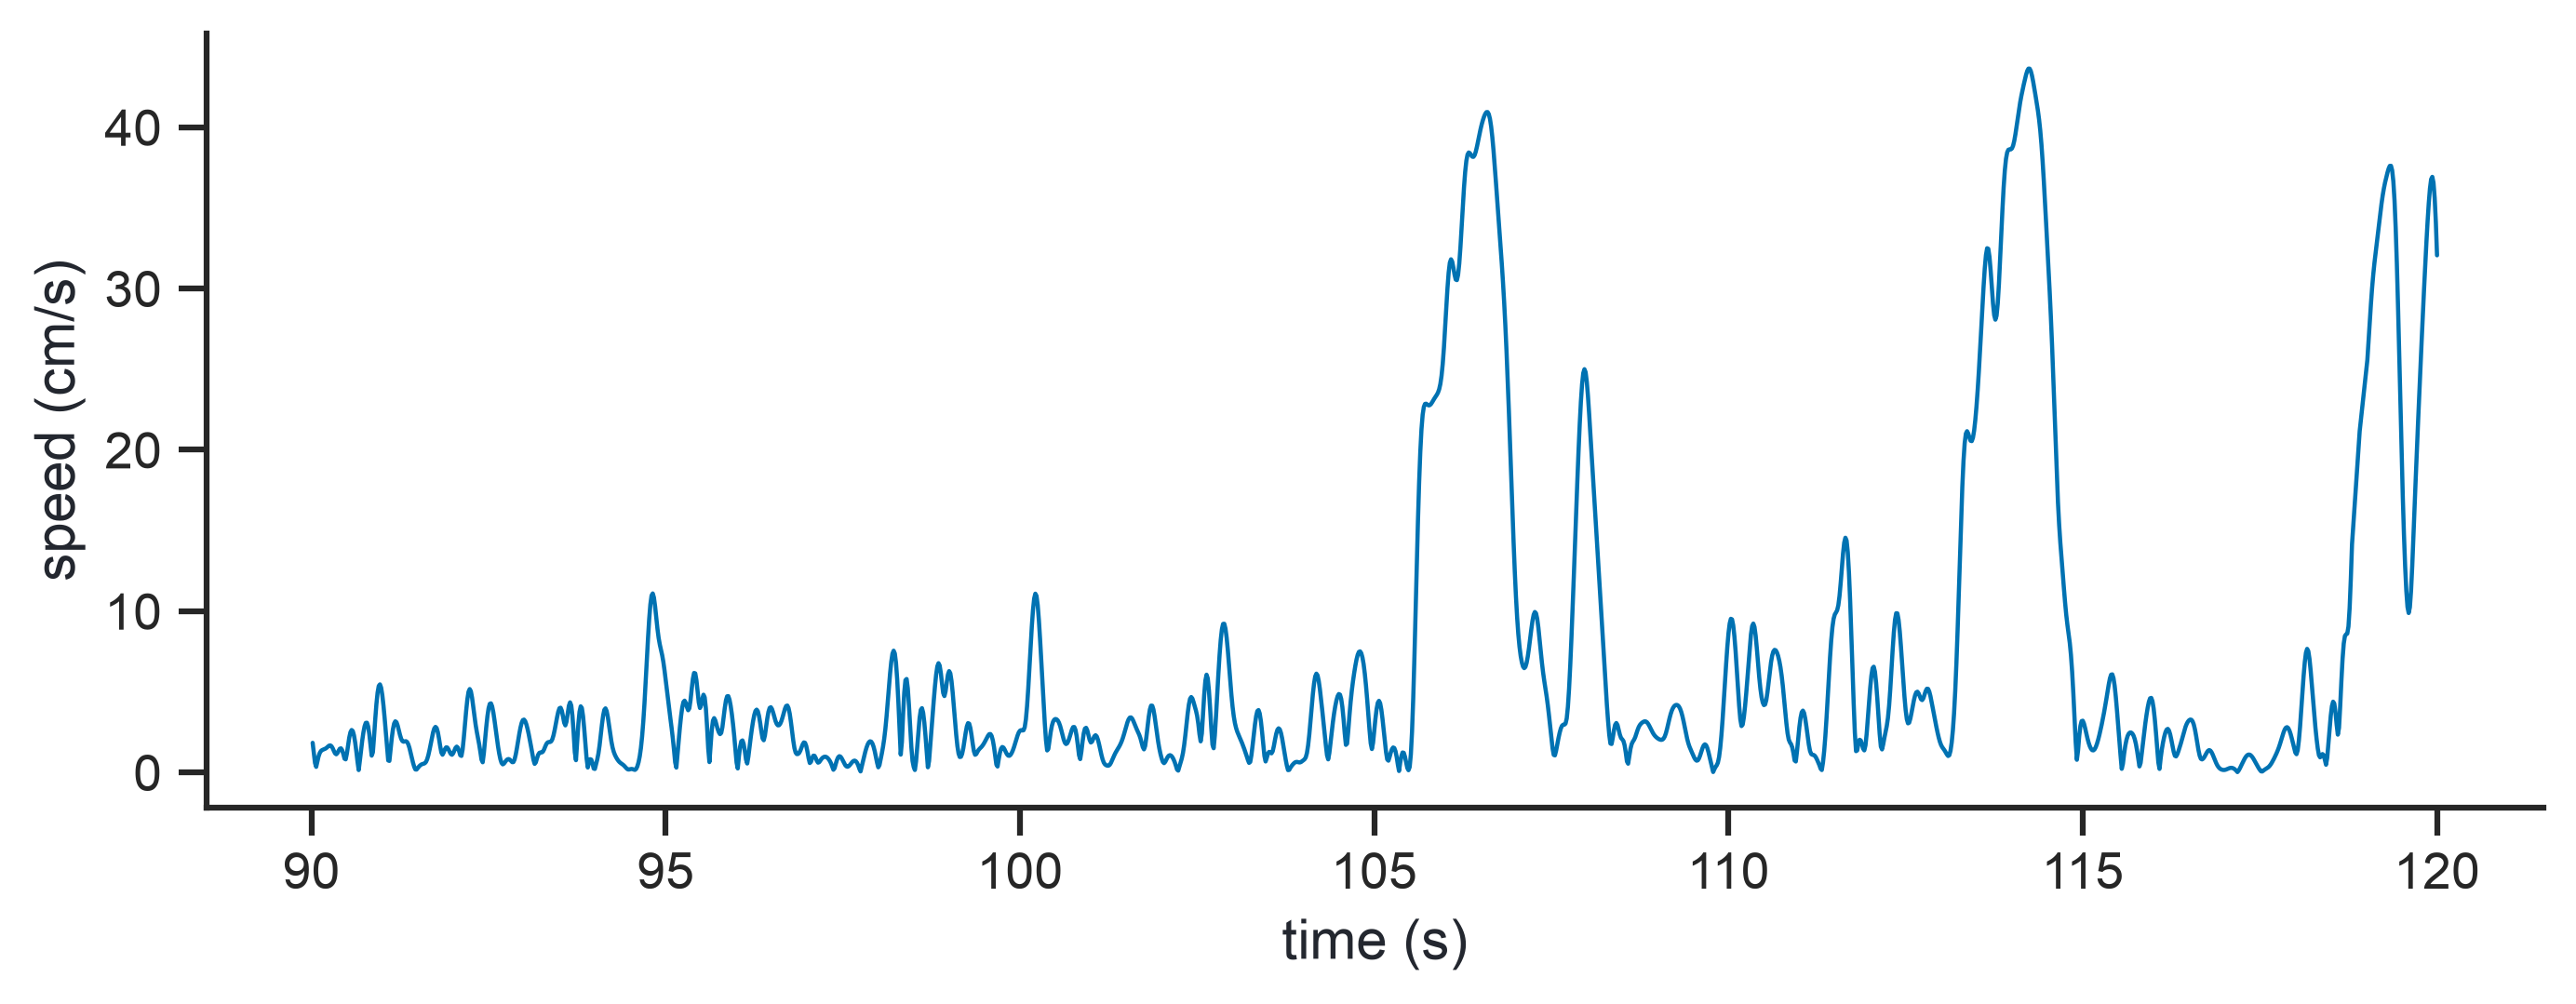

In [41]:
# Question: choose a time window for the speed trace.
# Use the same time range as the position data, then edit these values.
speed_window_start = 90
speed_window_stop = 120

speed_window_df = speed_df.query("@speed_window_start <= time <= @speed_window_stop")
if speed_window_df.empty:
    raise ValueError("No speed samples found in this window. Choose start and stop times within the session time range.")

print(f"Selected {len(speed_window_df)} speed samples from {speed_window_start} to {speed_window_stop} seconds.")

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(speed_window_df["time"], speed_window_df["speed"], color=COLORS["blue"], linewidth=0.9)
ax.set_xlabel("time (s)")
ax.set_ylabel("speed (cm/s)")
sns.despine(ax=ax)
plt.show()

We can also look at speed and position together:

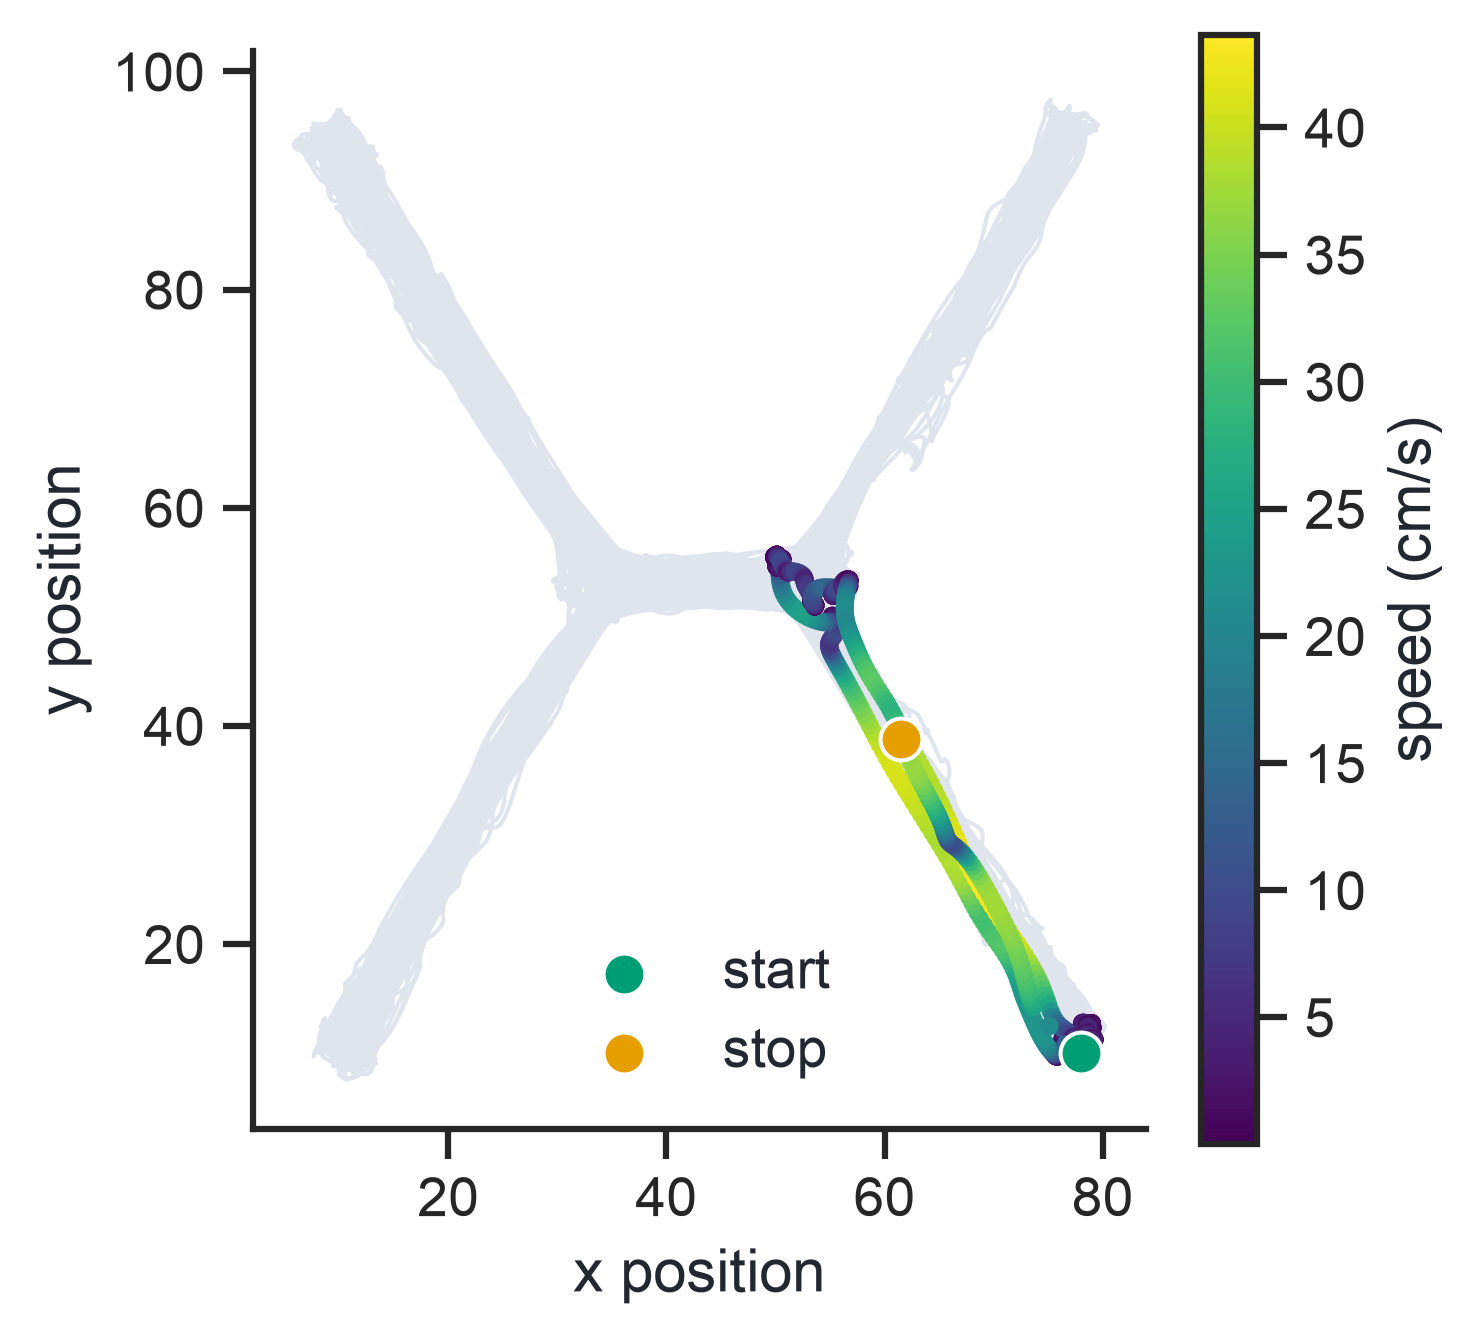

In [43]:
# Combine position and speed for the selected window.
# Speed was computed between consecutive position samples, so we use midpoint positions.
speed_position_df = speed_df.copy()
speed_position_df["x"] = (x[:-1] + x[1:]) / 2
speed_position_df["y"] = (y[:-1] + y[1:]) / 2

speed_position_window_df = speed_position_df.query(
    "@speed_window_start <= time <= @speed_window_stop"
)
if speed_position_window_df.empty:
    raise ValueError("No samples found in this window. Choose start and stop times within the session time range.")

fig, ax = plt.subplots(figsize=(4, 4))
ax.plot(position_df["x"], position_df["y"], color=COLORS["light_gray"], linewidth=0.8, alpha=0.8)
sc = ax.scatter(
    speed_position_window_df["x"],
    speed_position_window_df["y"],
    c=speed_position_window_df["speed"],
    s=7,
    cmap="viridis",
    zorder=3,
)
ax.scatter(
    speed_position_window_df["x"].iloc[0],
    speed_position_window_df["y"].iloc[0],
    color=COLORS["green"],
    edgecolor="white",
    linewidth=0.8,
    s=70,
    zorder=4,
    label="start",
)
ax.scatter(
    speed_position_window_df["x"].iloc[-1],
    speed_position_window_df["y"].iloc[-1],
    color=COLORS["orange"],
    edgecolor="white",
    linewidth=0.8,
    s=70,
    zorder=4,
    label="stop",
)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("x position")
ax.set_ylabel("y position")
plt.colorbar(sc, ax=ax, label="speed (cm/s)")
ax.legend(frameon=False, loc="best")
sns.despine(ax=ax)
plt.show()

We can also derive acceleration from speed.

Acceleration is the change in speed per unit time:

```text
acceleration = change in speed / change in time
```

Large positive values mean the animal is speeding up. Large negative values mean the animal is slowing down.

Small frame-to-frame changes in position can make raw speed noisy. Since acceleration is a derivative of speed, that noise gets amplified. Before computing acceleration, we will smooth speed with a window you can tune.

In [44]:
# Question: choose how much to smooth speed before computing acceleration.
speed_smoothing_window_s = 0.5
speed_sample_dt = np.median(np.diff(speed_time))
speed_smoothing_window_samples = max(1, int(round(speed_smoothing_window_s / speed_sample_dt)))
smoothed_speed = (
    pd.Series(speed)
    .rolling(speed_smoothing_window_samples, center=True, min_periods=1)
    .mean()
    .to_numpy()
)

print(f"Smoothing speed with a {speed_smoothing_window_s}-second window ({speed_smoothing_window_samples} samples).")

# Fill-in challenge: how should acceleration be computed from smoothed speed?
d_speed = np.diff(smoothed_speed)
d_speed_time = np.diff(speed_time)

acceleration = d_speed / d_speed_time
acceleration_time = speed_time[:-1] + d_speed_time / 2

acceleration_df = pd.DataFrame({"time": acceleration_time, "acceleration": acceleration})
display(acceleration_df.head())

Smoothing speed with a 0.5-second window (30 samples).


,time,acceleration
0,4.458297,-1.067780
1,4.474963,-1.160040
2,4.491630,-1.557659
3,4.508297,-2.097471
4,4.524963,-1.143137


Now plot acceleration over a selected time window. Try changing `speed_smoothing_window_s` above and rerun these cells to see how smoothing changes the acceleration trace.

Selected 1788 acceleration samples from 90 to 120 seconds.


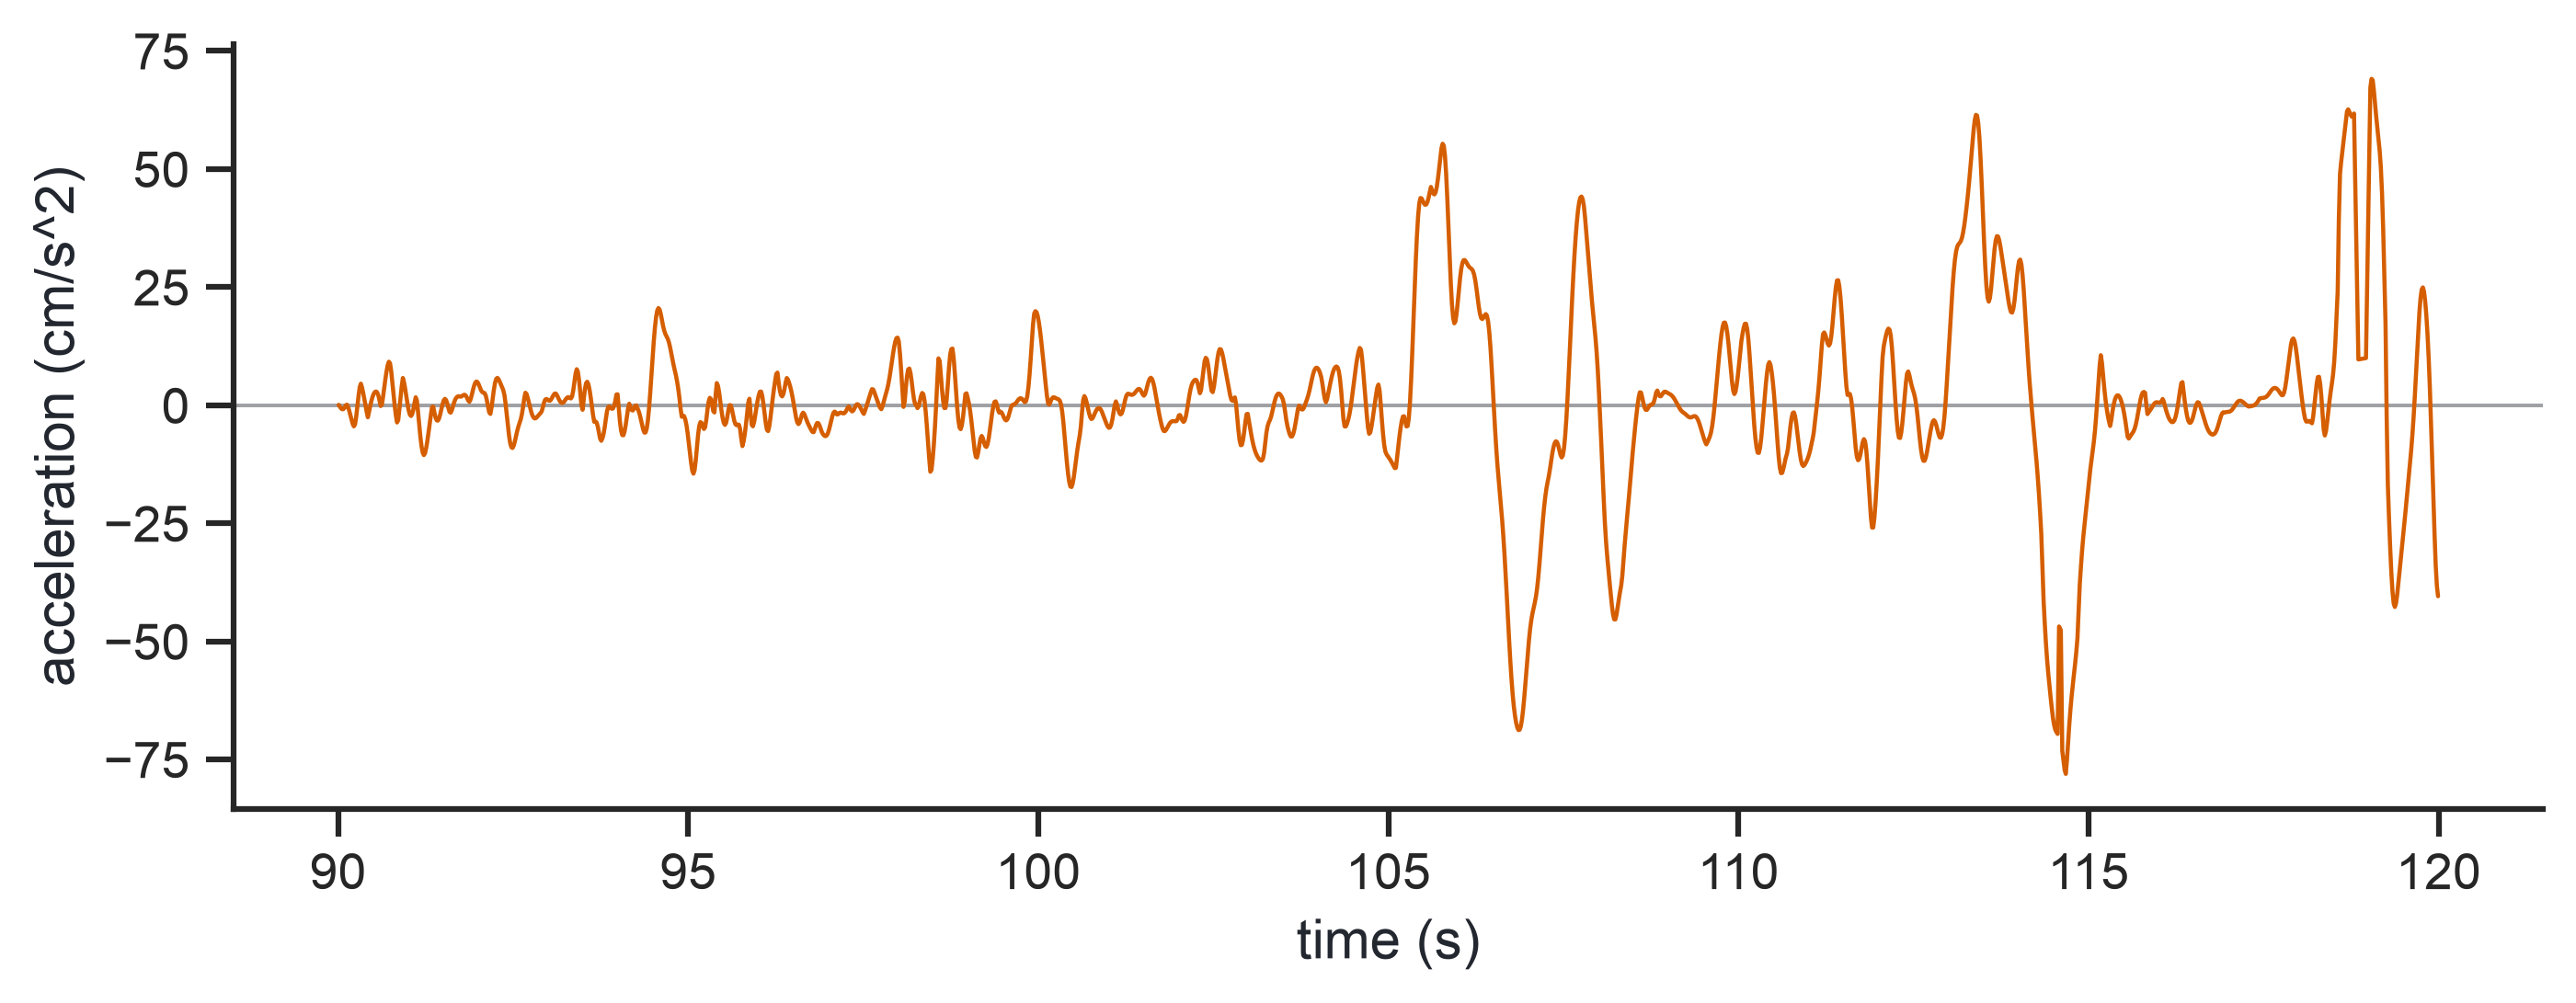

In [45]:
# Use the same window as the speed plot by default, or edit these values.
acceleration_window_start = speed_window_start
acceleration_window_stop = speed_window_stop

acceleration_window_df = acceleration_df.query(
    "@acceleration_window_start <= time <= @acceleration_window_stop"
)
if acceleration_window_df.empty:
    raise ValueError("No acceleration samples found in this window. Choose start and stop times within the session time range.")

print(f"Selected {len(acceleration_window_df)} acceleration samples from {acceleration_window_start} to {acceleration_window_stop} seconds.")

fig, ax = plt.subplots(figsize=(9, 3))
ax.axhline(0, color=COLORS["gray"], linewidth=0.8, alpha=0.6)
ax.plot(acceleration_window_df["time"], acceleration_window_df["acceleration"], color=COLORS["vermillion"], linewidth=0.9)
ax.set_xlabel("time (s)")
ax.set_ylabel("acceleration (cm/s^2)")
sns.despine(ax=ax)
plt.show()

We can also look at acceleration and position together.

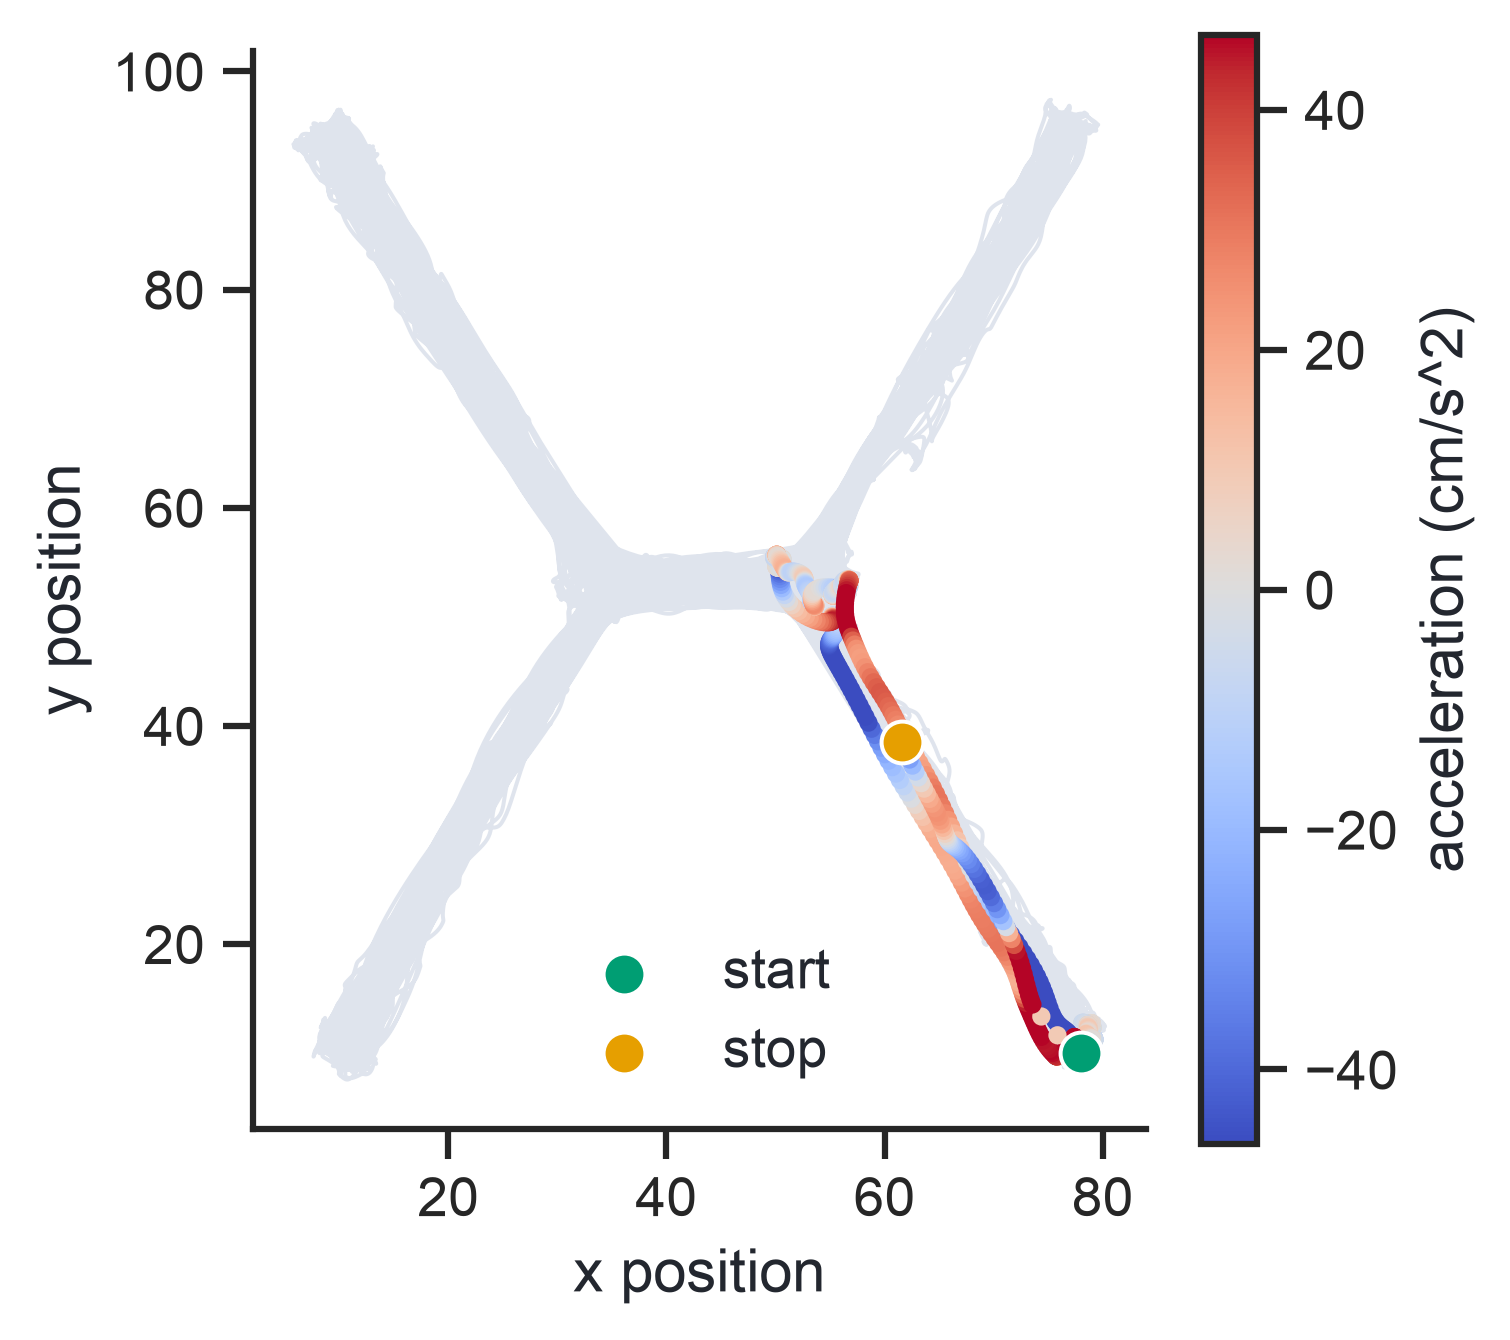

In [47]:
# Acceleration was computed between consecutive speed samples, so use midpoint positions again.
acceleration_position_df = acceleration_df.copy()
speed_x = (x[:-1] + x[1:]) / 2
speed_y = (y[:-1] + y[1:]) / 2
acceleration_position_df["x"] = (speed_x[:-1] + speed_x[1:]) / 2
acceleration_position_df["y"] = (speed_y[:-1] + speed_y[1:]) / 2

acceleration_position_window_df = acceleration_position_df.query(
    "@acceleration_window_start <= time <= @acceleration_window_stop"
)
if acceleration_position_window_df.empty:
    raise ValueError("No samples found in this window. Choose start and stop times within the session time range.")

accel_abs_max = np.nanpercentile(np.abs(acceleration_position_window_df["acceleration"]), 95)
if accel_abs_max == 0:
    accel_abs_max = 1

fig, ax = plt.subplots(figsize=(4, 4))
ax.plot(position_df["x"], position_df["y"], color=COLORS["light_gray"], linewidth=0.8, alpha=0.8)
sc = ax.scatter(
    acceleration_position_window_df["x"],
    acceleration_position_window_df["y"],
    c=acceleration_position_window_df["acceleration"],
    s=7,
    cmap="coolwarm",
    vmin=-accel_abs_max,
    vmax=accel_abs_max,
    zorder=3,
)
ax.scatter(
    acceleration_position_window_df["x"].iloc[0],
    acceleration_position_window_df["y"].iloc[0],
    color=COLORS["green"],
    edgecolor="white",
    linewidth=0.8,
    s=70,
    zorder=4,
    label="start",
)
ax.scatter(
    acceleration_position_window_df["x"].iloc[-1],
    acceleration_position_window_df["y"].iloc[-1],
    color=COLORS["orange"],
    edgecolor="white",
    linewidth=0.8,
    s=70,
    zorder=4,
    label="stop",
)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("x position")
ax.set_ylabel("y position")
plt.colorbar(sc, ax=ax, label="acceleration (cm/s^2)")
ax.legend(frameon=False, loc="best")
sns.despine(ax=ax)
plt.show()

## 6. Inspect Units And Brain Regions

Neuropixels probes record along a long, thin shank that can pass through several structures on its way to the target region. Even in a session aimed at MEC and CA1, some recorded units may end up assigned to a neighboring structure, such as dentate gyrus, CA3, or visual cortex, depending on exactly where each electrode sits along the shank. The `units` table in this dataset does not label each neuron by region, but each unit is linked to the electrode(s) that recorded it, and the `electrodes` table records the anatomical location of each electrode. Combining the two tells us which region each unit came from.

First, inspect the size of the recording table. The `units` table tells us how many neurons were sorted, and the `electrodes` table tells us where the recording channels were located.

In [51]:
units_table = nwb.units
unit_ids = np.asarray(units_table.id[:])
electrodes_df = nwb.electrodes.to_dataframe()

print(f"Number of units: {len(unit_ids)}")
print(f"Number of electrodes: {len(electrodes_df)}")
print("Unit columns:", list(units_table.colnames))

if "location" in electrodes_df.columns:
    display(electrodes_df["location"].value_counts().rename("n_electrodes").to_frame())
else:
    print("No location column found in electrodes table.")


Number of units: 415
Number of electrodes: 768
Unit columns: ['spike_times', 'electrodes', 'electrode_group']


,n_electrodes
location,
CA1,152
ENTm5,140
ENTm2,126
ENTm3,118
DG-mo,40
CA3,38
cing,34
DG-sg,30
ccb,28


Next, count how many units are assigned to each brain region. 

In [52]:
def get_unit_spike_times(unit_id):
    return np.asarray(fetch_unit_spike_times(units_table, unit_ids, unit_id))

spike_time_ends = np.asarray(units_table["spike_times_index"].data[:])
total_spikes = np.diff(np.r_[0, spike_time_ends])
regions = [unit_region_from_row(units_table, row_i, electrodes_df) for row_i in range(len(unit_ids))]

units_df = pd.DataFrame(
    {
        "unit_id": unit_ids,
        "region": regions,
        "total_spikes": total_spikes,
    },
    index=unit_ids,
)
units_df.index.name = "unit_id"

display(units_df["region"].value_counts().rename("n_units").to_frame())

,n_units
region,
CA1,132
DG-mo,66
CA3,52
RSPagl6a,37
ccb,35
DG-sg,31
cing,28
DG-po,13
SSp-tr6b,8


We will focus on CA1 for the spatial firing analysis.

CA1 is the classic region for studying place cells, first described by O'Keefe and Dostrovsky in 1971. 

In [53]:
region_filter = "CA1"

region_units = units_df.query("region == @region_filter").copy()
region_units["firing_rate_hz"] = region_units["total_spikes"] / (time[-1] - time[0]) #complete the expression to calculate firing rate

median_rate_hz = region_units["firing_rate_hz"].median()
region_units["rate_distance"] = (region_units["firing_rate_hz"] - median_rate_hz).abs()

print(f"Region: {region_filter}")
print(f"Units in region: {len(region_units)}")
print(f"Median firing rate: {median_rate_hz:.2f} Hz")

Region: CA1
Units in region: 132
Median firing rate: 0.23 Hz


## 7. Select Putative Pyramidal Cells

We will use a simple firing-rate filter to define a pool of putative CA1 pyramidal cells. Keep units above 0.1 Hz, then choose a reasonable high-rate cutoff and inspect the filtered pool before choosing one `unit_id` for the rest of the analysis.

In [ ]:
high_rate_cutoff_hz = 5
min_rate_hz = 0.1

candidate_units = region_units[
    (region_units["firing_rate_hz"] >= min_rate_hz)
    & (region_units["firing_rate_hz"] < high_rate_cutoff_hz)
].copy()
candidate_units = candidate_units.sort_index()

print(f"Region: {region_filter}")
print(f"Selected firing-rate range: {min_rate_hz} to {high_rate_cutoff_hz} Hz")
print(f"Number of filtered units: {len(candidate_units)}")
print("Cell IDs:")
print(candidate_units.index.to_list())


Region: CA1
Selected firing-rate range: 0.1 to 5 Hz
Number of filtered units: 180
Cell IDs:
[4, 5, 6, 7, 8, 9, 10, 17, 18, 19, 20, 21, 23, 28, 29, 30, 34, 37, 38, 39, 40, 41, 57, 58, 67, 68, 73, 74, 75, 101, 104, 105, 106, 125, 127, 130, 131, 132, 133, 134, 135, 150, 151, 152, 154, 155, 156, 157, 158, 159, 160, 162, 163, 164, 165, 166, 179, 190, 191, 194, 196, 199, 200, 205, 206, 207, 208, 209, 210, 212, 214, 215, 216, 243, 244, 245, 247, 248, 249, 250, 251, 253, 256, 257, 284, 287, 289, 290, 291, 292, 293, 297, 298, 299, 300, 301, 303, 308, 309, 310, 311, 312, 315, 318, 319, 333, 336, 337, 340, 342, 344, 347, 402, 403, 404, 405, 406, 408, 409, 410, 411, 414, 416, 418, 420, 421, 469, 470, 471, 472, 473, 475, 477, 479, 483, 485, 486, 488, 491, 497, 498, 499, 501, 503, 505, 509, 510, 511, 512, 516, 517, 518, 519, 520, 521, 523, 525, 545, 546, 547, 548, 549, 555, 556, 558, 564, 566, 582, 584, 588, 589, 592, 593, 594, 595, 596, 597, 603, 604, 607]


Now look at a short raster from up to 20 units in that filtered pool. This gives a quick sense of how diverse their spike timing looks before choosing one cell to follow.


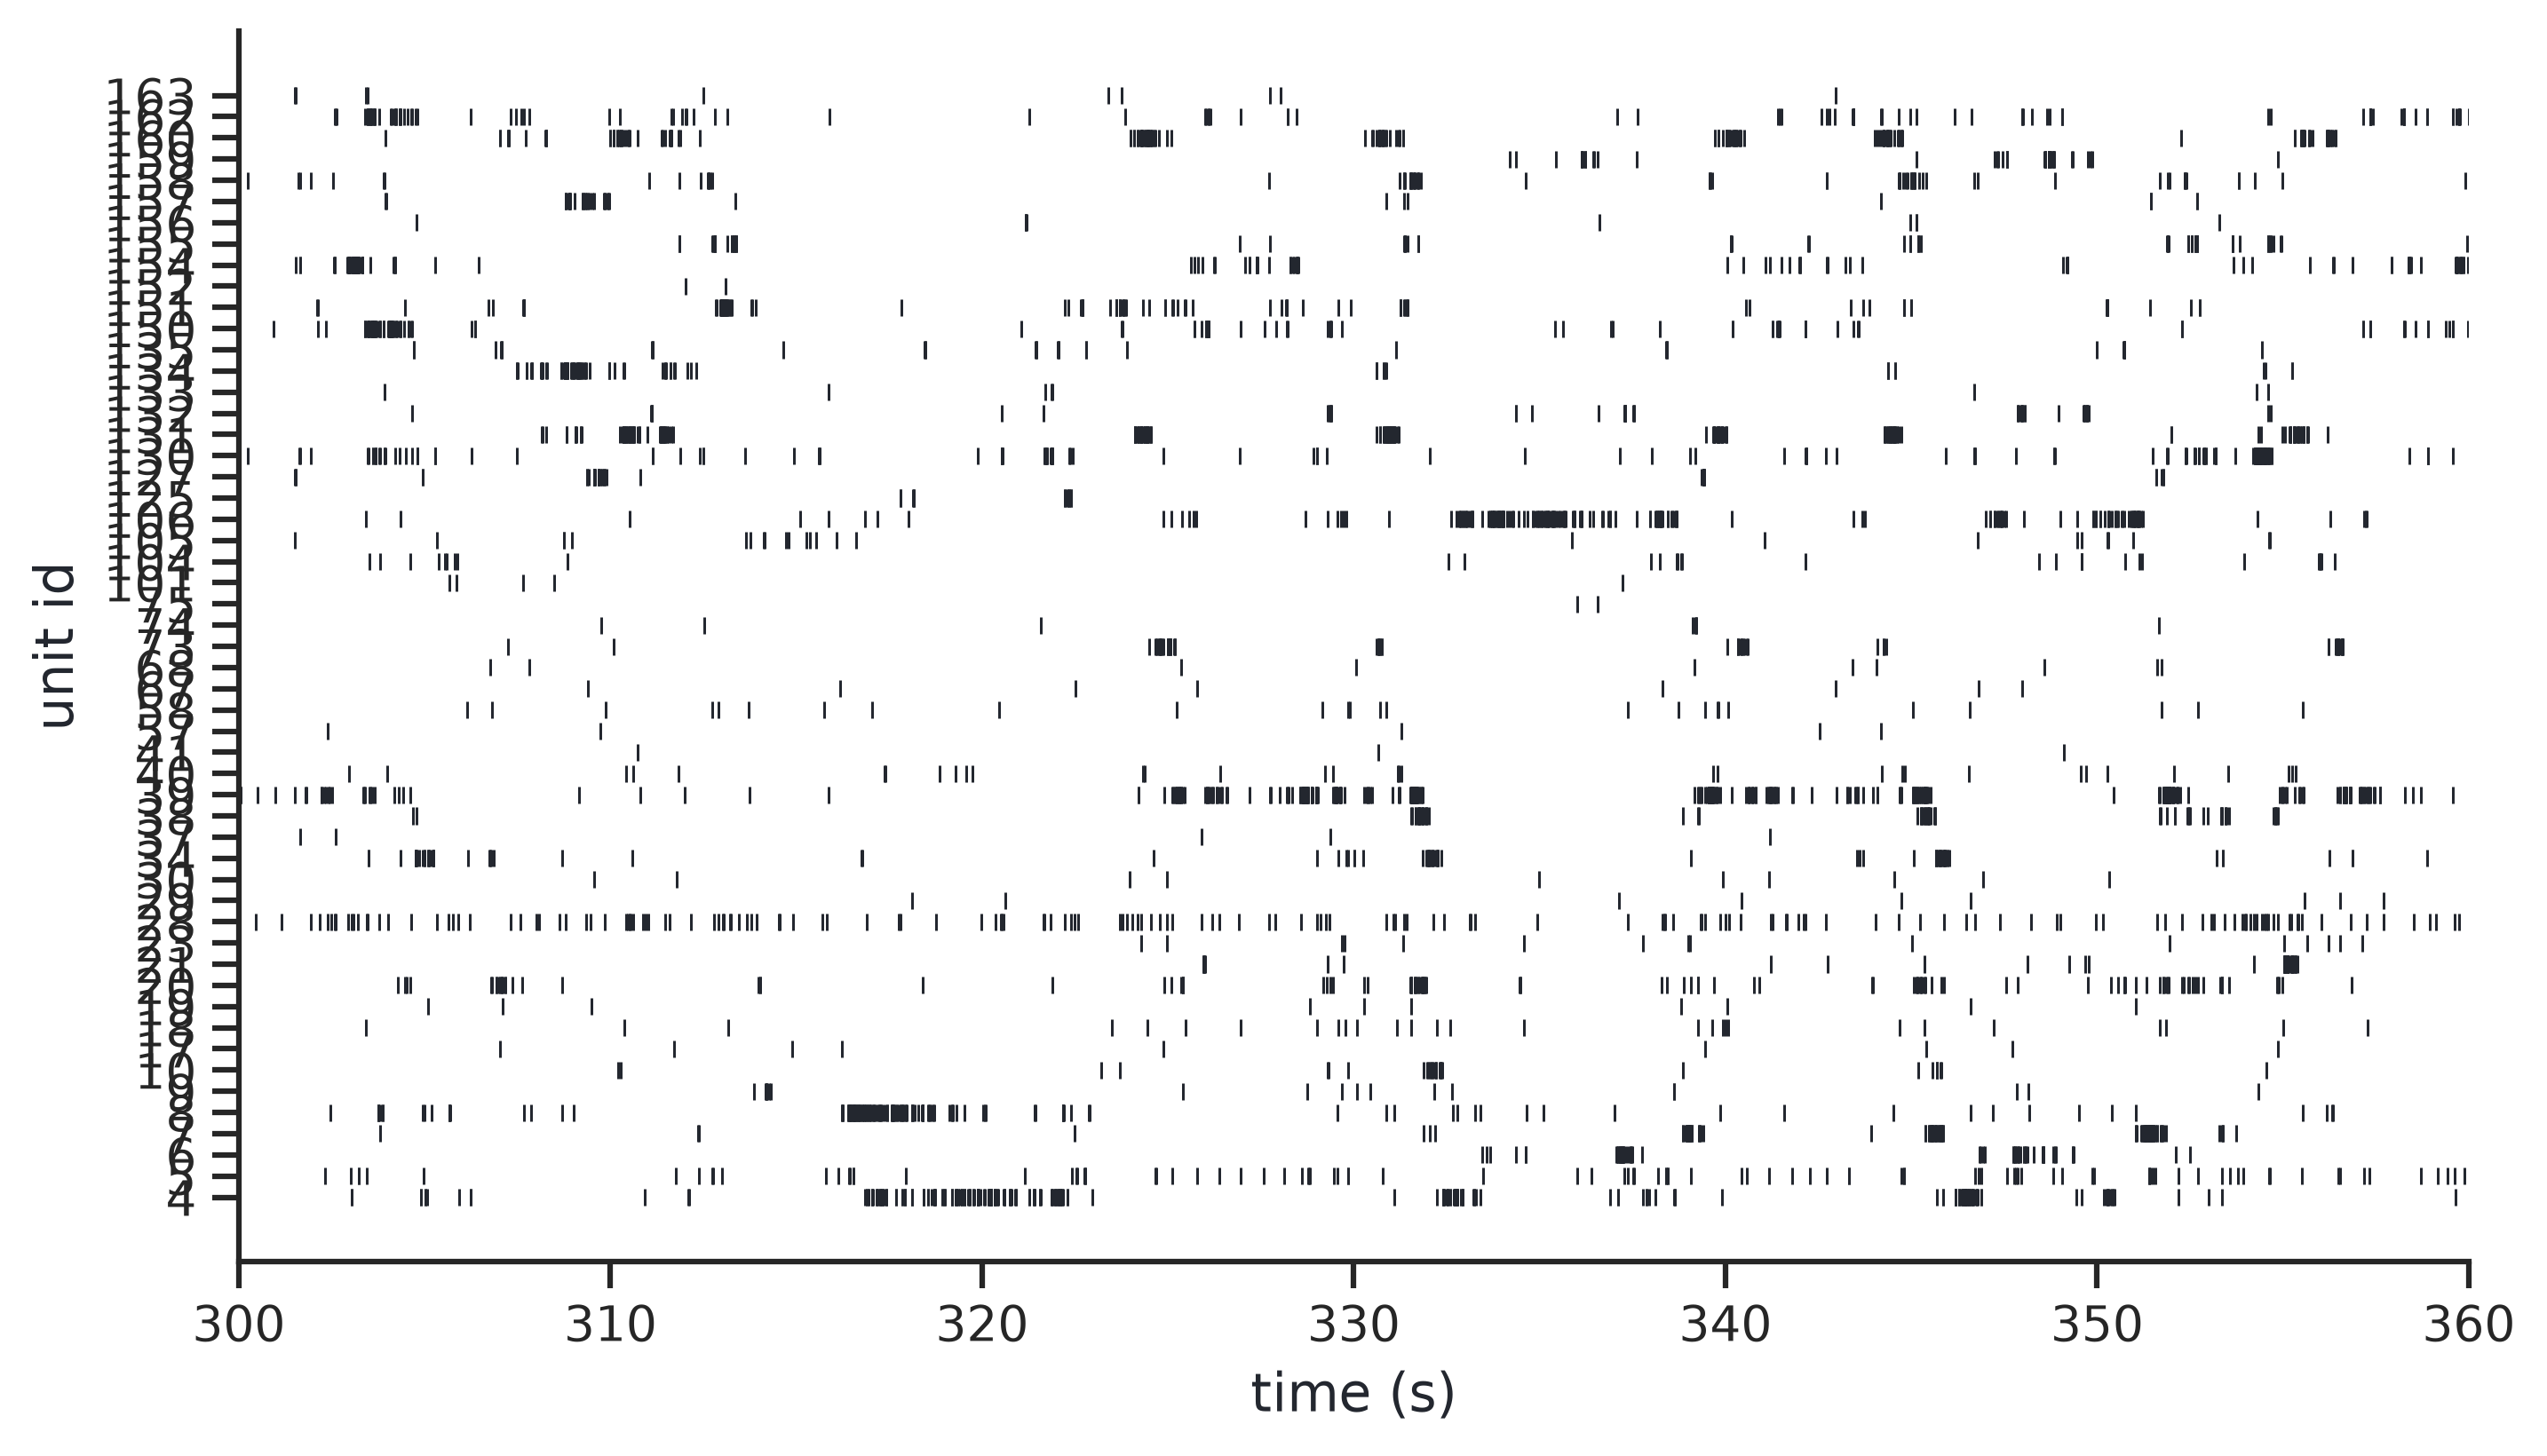

In [85]:
raster_start_time = 300.0
raster_stop_time = 360.0
n_raster_units = min(53, len(candidate_units))
raster_unit_ids = candidate_units.index[:n_raster_units].to_list()

fig, ax = plt.subplots(figsize=(9, 5))
for row_i, raster_unit_id in enumerate(raster_unit_ids):
    spikes = get_unit_spike_times(raster_unit_id)
    spikes = spikes[(spikes >= raster_start_time) & (spikes <= raster_stop_time)]
    ax.vlines(spikes, row_i + 0.1, row_i + 0.9, color=COLORS["dark"], linewidth=0.6)

ax.set_xlabel("time (s)")
ax.set_ylabel("unit id")
ax.set_yticks(np.arange(len(raster_unit_ids)) + 0.5)
ax.set_yticklabels(raster_unit_ids)
ax.set_xlim(raster_start_time, raster_stop_time)
sns.despine(ax=ax)
plt.show()


**Questions**

- Do some filtered CA1 units fire much more than others in the same time window?
- Are spikes spread evenly through time, or do some units fire in brief bursts?


Pick one `unit_id` from the filtered list above. Different participants or groups can choose different cells at random and compare what they find.

In [87]:
# Choose a unit_id from the filtered list above.
unit_id = 20

unit_spike_times = get_unit_spike_times(unit_id)
unit_spike_times = unit_spike_times[(unit_spike_times >= time[0]) & (unit_spike_times <= time[-1])]

print("unit_id:", unit_id)
print("region:", units_df.loc[unit_id, "region"])
print("firing rate (Hz):", round(region_units.loc[unit_id, "firing_rate_hz"], 2))
print("total spikes in session:", len(unit_spike_times))


unit_id: 20
region: CA1
firing rate (Hz): 1.98
total spikes in session: 4788


## 8. Spike Locations On The Maze

We now have two ingredients:
- `unit_spike_times`: when this unit fired
- `time`, `x`, and `y`: the animal's position sampled over time

These are not defined on the same time grid. The tracking system sampled position frame by frame, while spikes can occur at any moment in between.

Here we follow the paper's simpler plotting convention:
- bin spike times onto the position timestamp grid,
- mark the position samples from frames that contained at least one spike.

So this plot answers a practical question: during which tracked positions did this unit fire on at least one frame?

That is slightly different from interpolation, which would estimate a continuous position at each exact spike time.


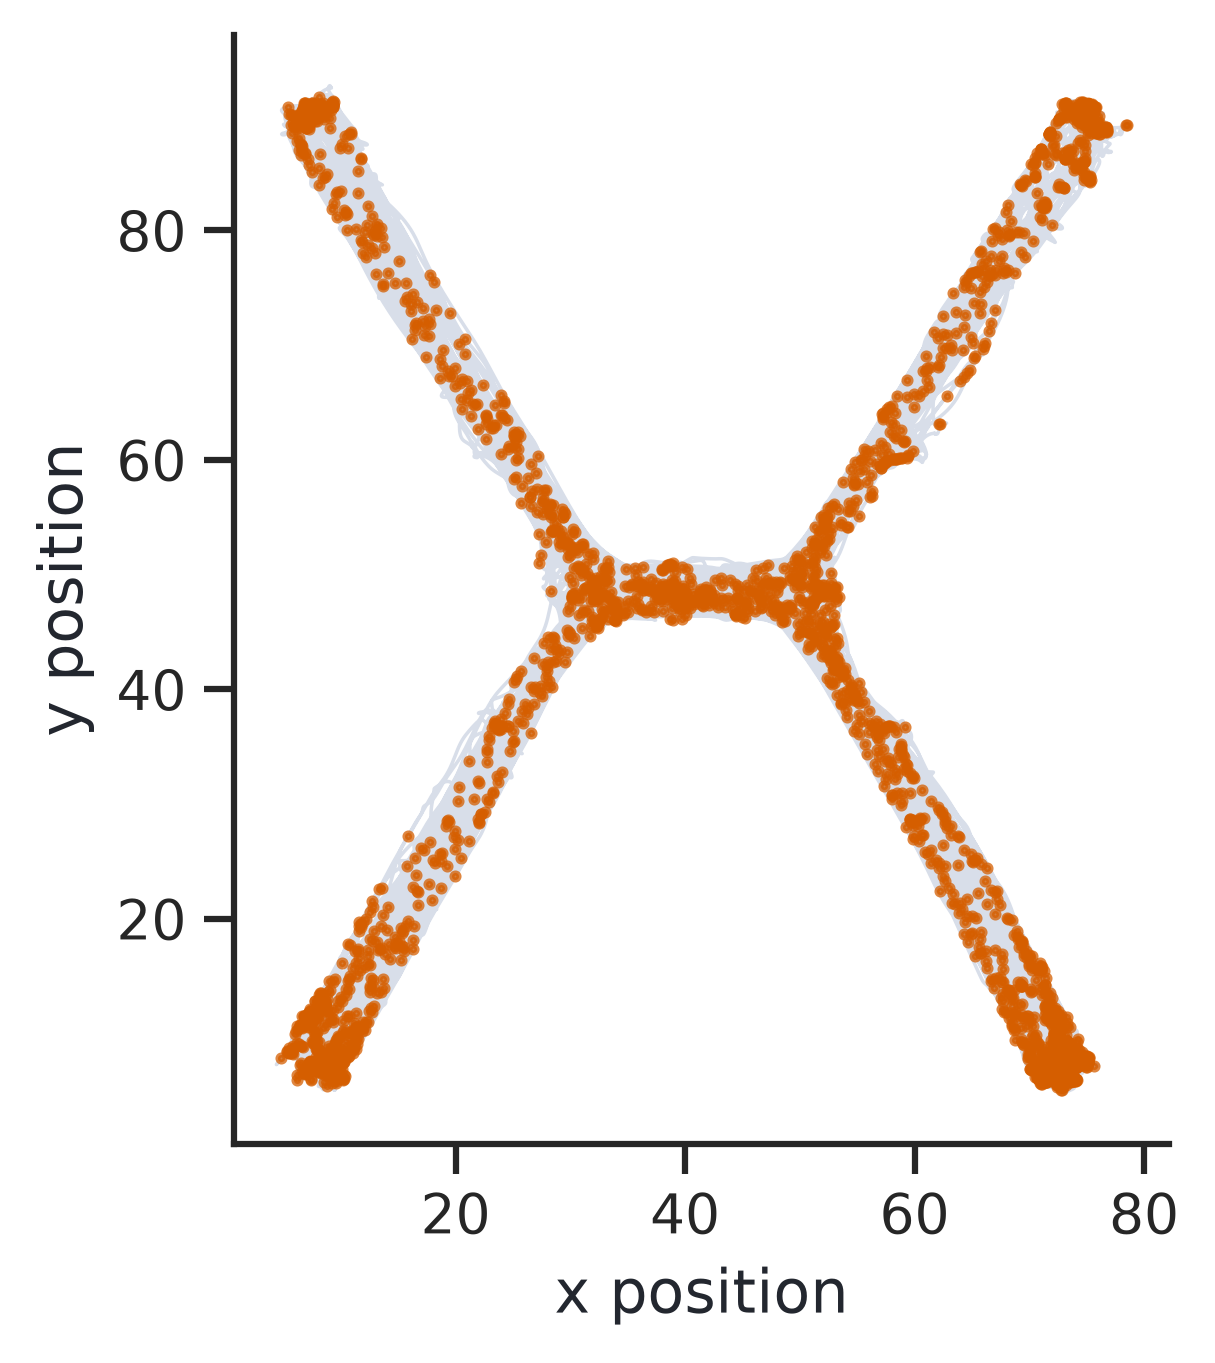

In [88]:
# Match the paper's plotting method: assign spikes to tracked position frames.
spike_positions = map_spikes_to_position_frames(unit_spike_times, time, x, y)
spike_x = spike_positions["spike_x"]
spike_y = spike_positions["spike_y"]

fig, ax = plt.subplots(figsize=(4, 4))
ax.plot(x, y, color=COLORS["light_gray"], linewidth=0.7, zorder=1)
ax.scatter(spike_x, spike_y, s=2, color=COLORS["vermillion"], alpha=0.75, zorder=2)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("x position")
ax.set_ylabel("y position")
sns.despine(ax=ax)
plt.show()


**Questions**

- Are spike locations clustered?
- Could clustering be explained by where the animal spent more time?

### Occupancy

The spike-location plot above shows where this unit fired, but not where the animal spent time. A cluster of spikes in one arm of the maze could mean the neuron prefers that location, or it could simply mean the animal lingered there. Spike locations alone cannot distinguish these two explanations, so they are not enough evidence for a place cell on their own.

Occupancy is the amount of time the animal spent in each spatial bin. Correcting for it is what turns a spike-location plot into a firing-rate estimate:

```text
firing rate at position = spikes at position / time spent at position
```

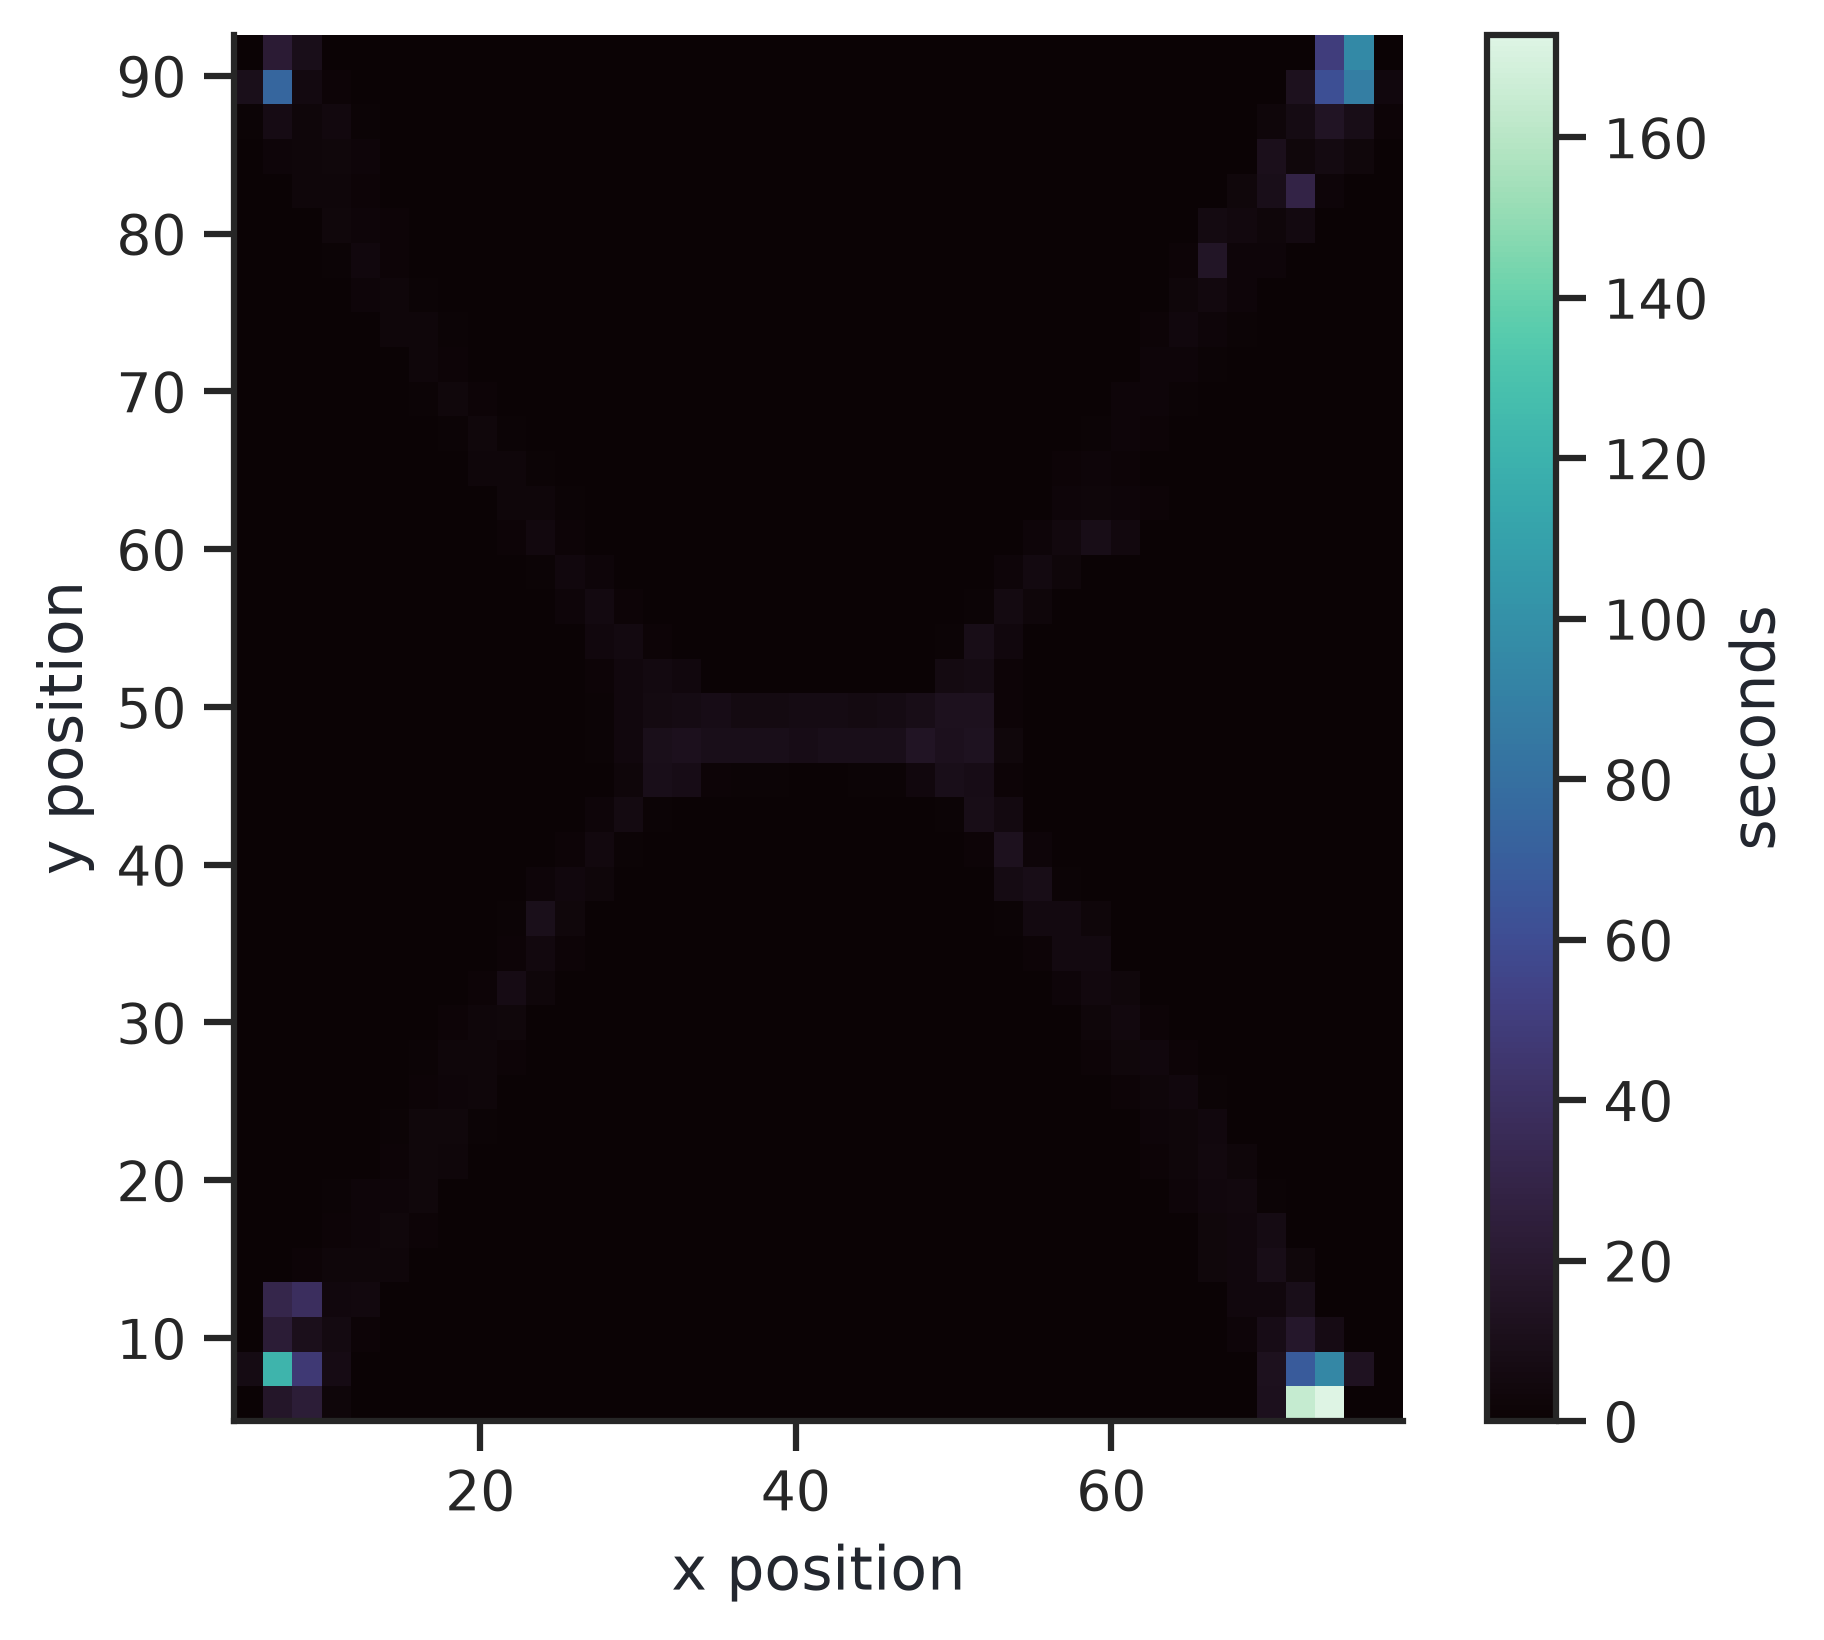

In [89]:
n_bins = 40

occupancy, x_edges, y_edges = compute_occupancy_map(x, y, dt, n_bins)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(
    occupancy.T,
    origin="lower",
    extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]],
    aspect="equal",
    cmap="mako",
)
ax.set_xlabel("x position")
ax.set_ylabel("y position")
plt.colorbar(im, ax=ax, label="seconds")
sns.despine(ax=ax)
plt.show()


**Questions**

- Compare this occupancy map to the spike-location plot above. Do the densest spike clusters line up with the most-visited locations?
- Given that comparison, would you trust the spike-location plot alone as evidence this is a place cell? Why or why not?

## 9. Rate Maps

We now have the two ingredients needed for a rate map:

- where the unit fired,
- how much time the animal spent in each part of the maze.

A rate map combines these by dividing spike count by occupancy in each spatial bin. This is what turns a spike-location plot into an estimate of firing rate across space.

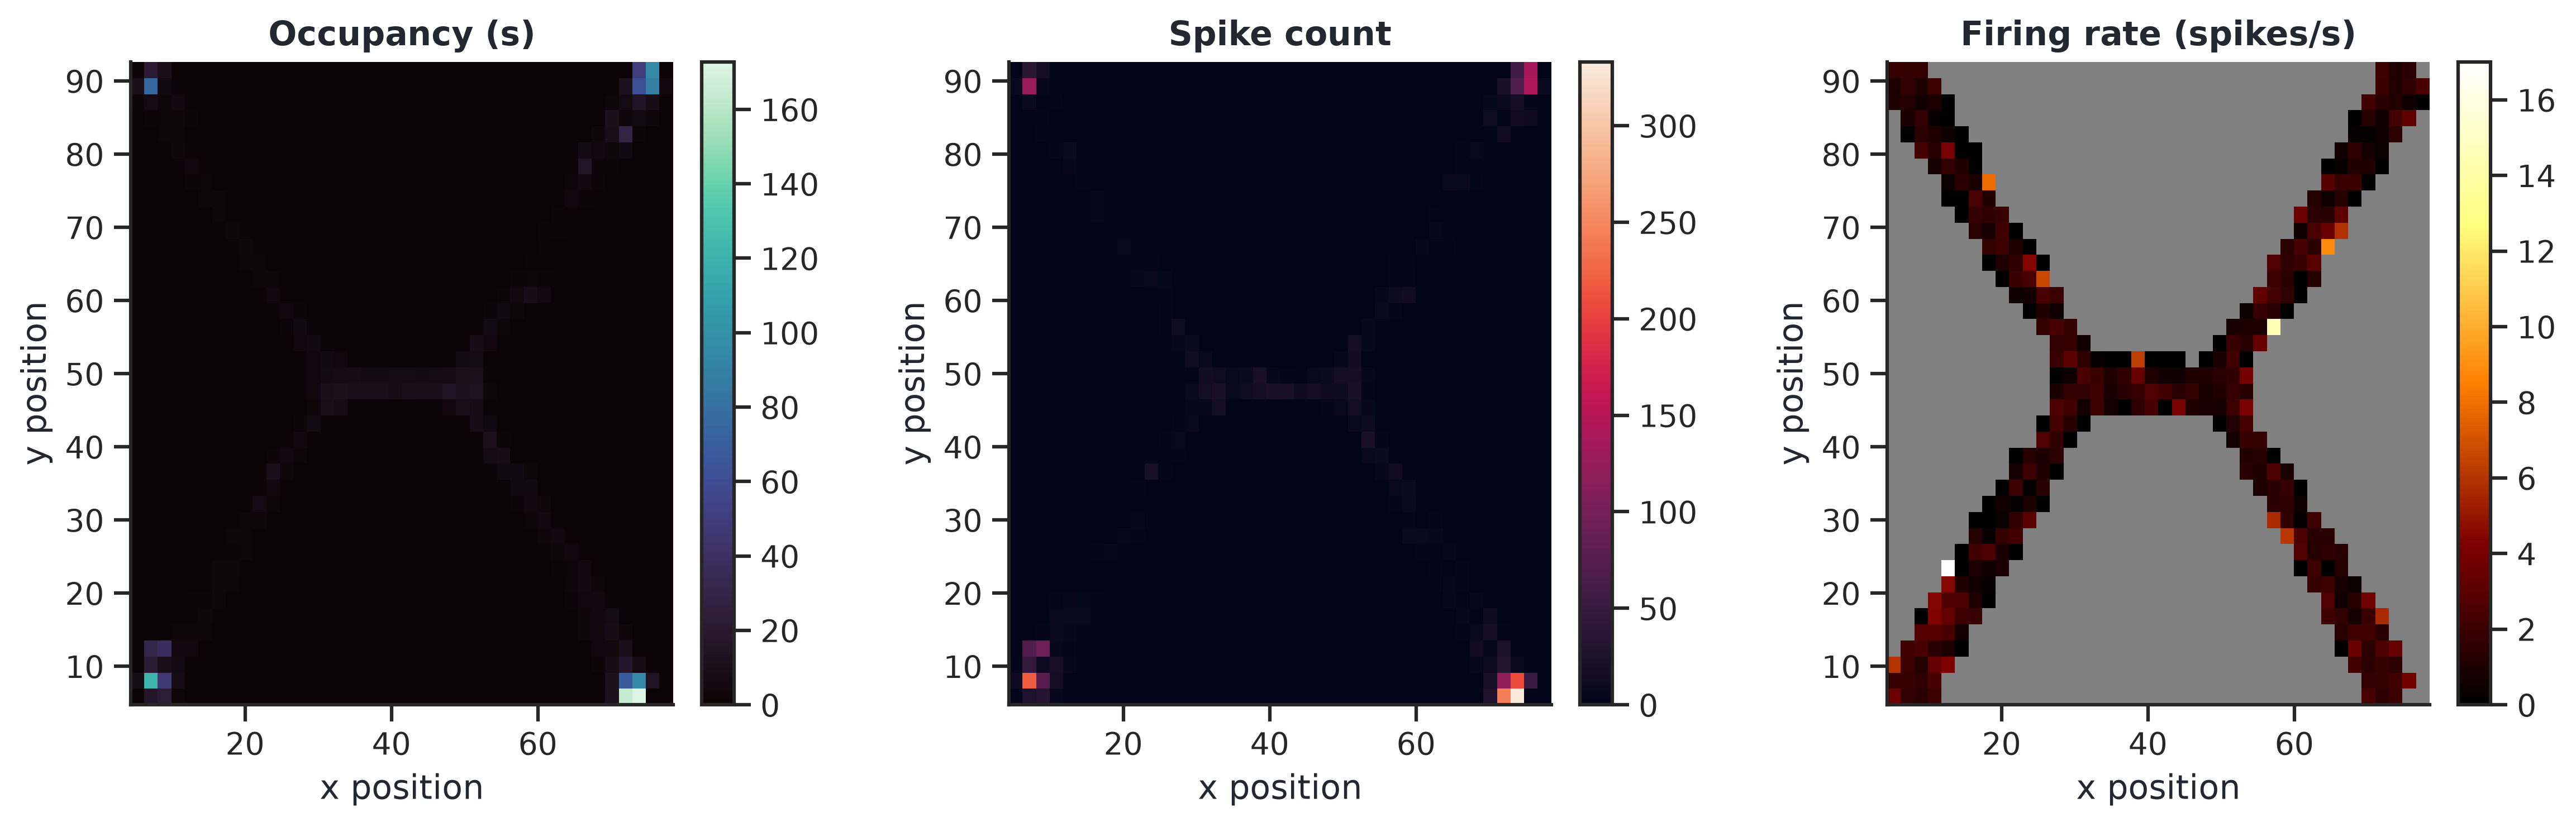

In [90]:
rate_map_result = compute_rate_map(
    unit_spike_times,
    time,
    x,
    y,
    x_edges,
    y_edges,
    occupancy,
    min_occupancy=0.1,
)
spike_counts = rate_map_result["spike_counts"]
rate_map = rate_map_result["rate_map"]

min_occupancy = 0.1

fig, axes = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)

maps = [occupancy, spike_counts, rate_map]
titles = ["Occupancy (s)", "Spike count", "Firing rate (spikes/s)"]
cmaps = ["mako", "rocket", RATE_MAP_CMAP]

for ax, data, title, cmap in zip(axes, maps, titles, cmaps):
    im = ax.imshow(
        data.T,
        origin="lower",
        extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]],
        aspect="equal",
        cmap=cmap,
    )
    ax.set_title(title)
    ax.set_xlabel("x position")
    ax.set_ylabel("y position")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    sns.despine(ax=ax)

plt.show()


Smoothing reduces bin-to-bin noise and makes broader spatial structure easier to see. Here we smooth the spike-count map and the occupancy map separately with a small Gaussian kernel, then divide them to get the final smoothed rate map. 

**Question: why do we smooth the spike-count and occupancy maps seperately? Why not just smooth the final rate map?**

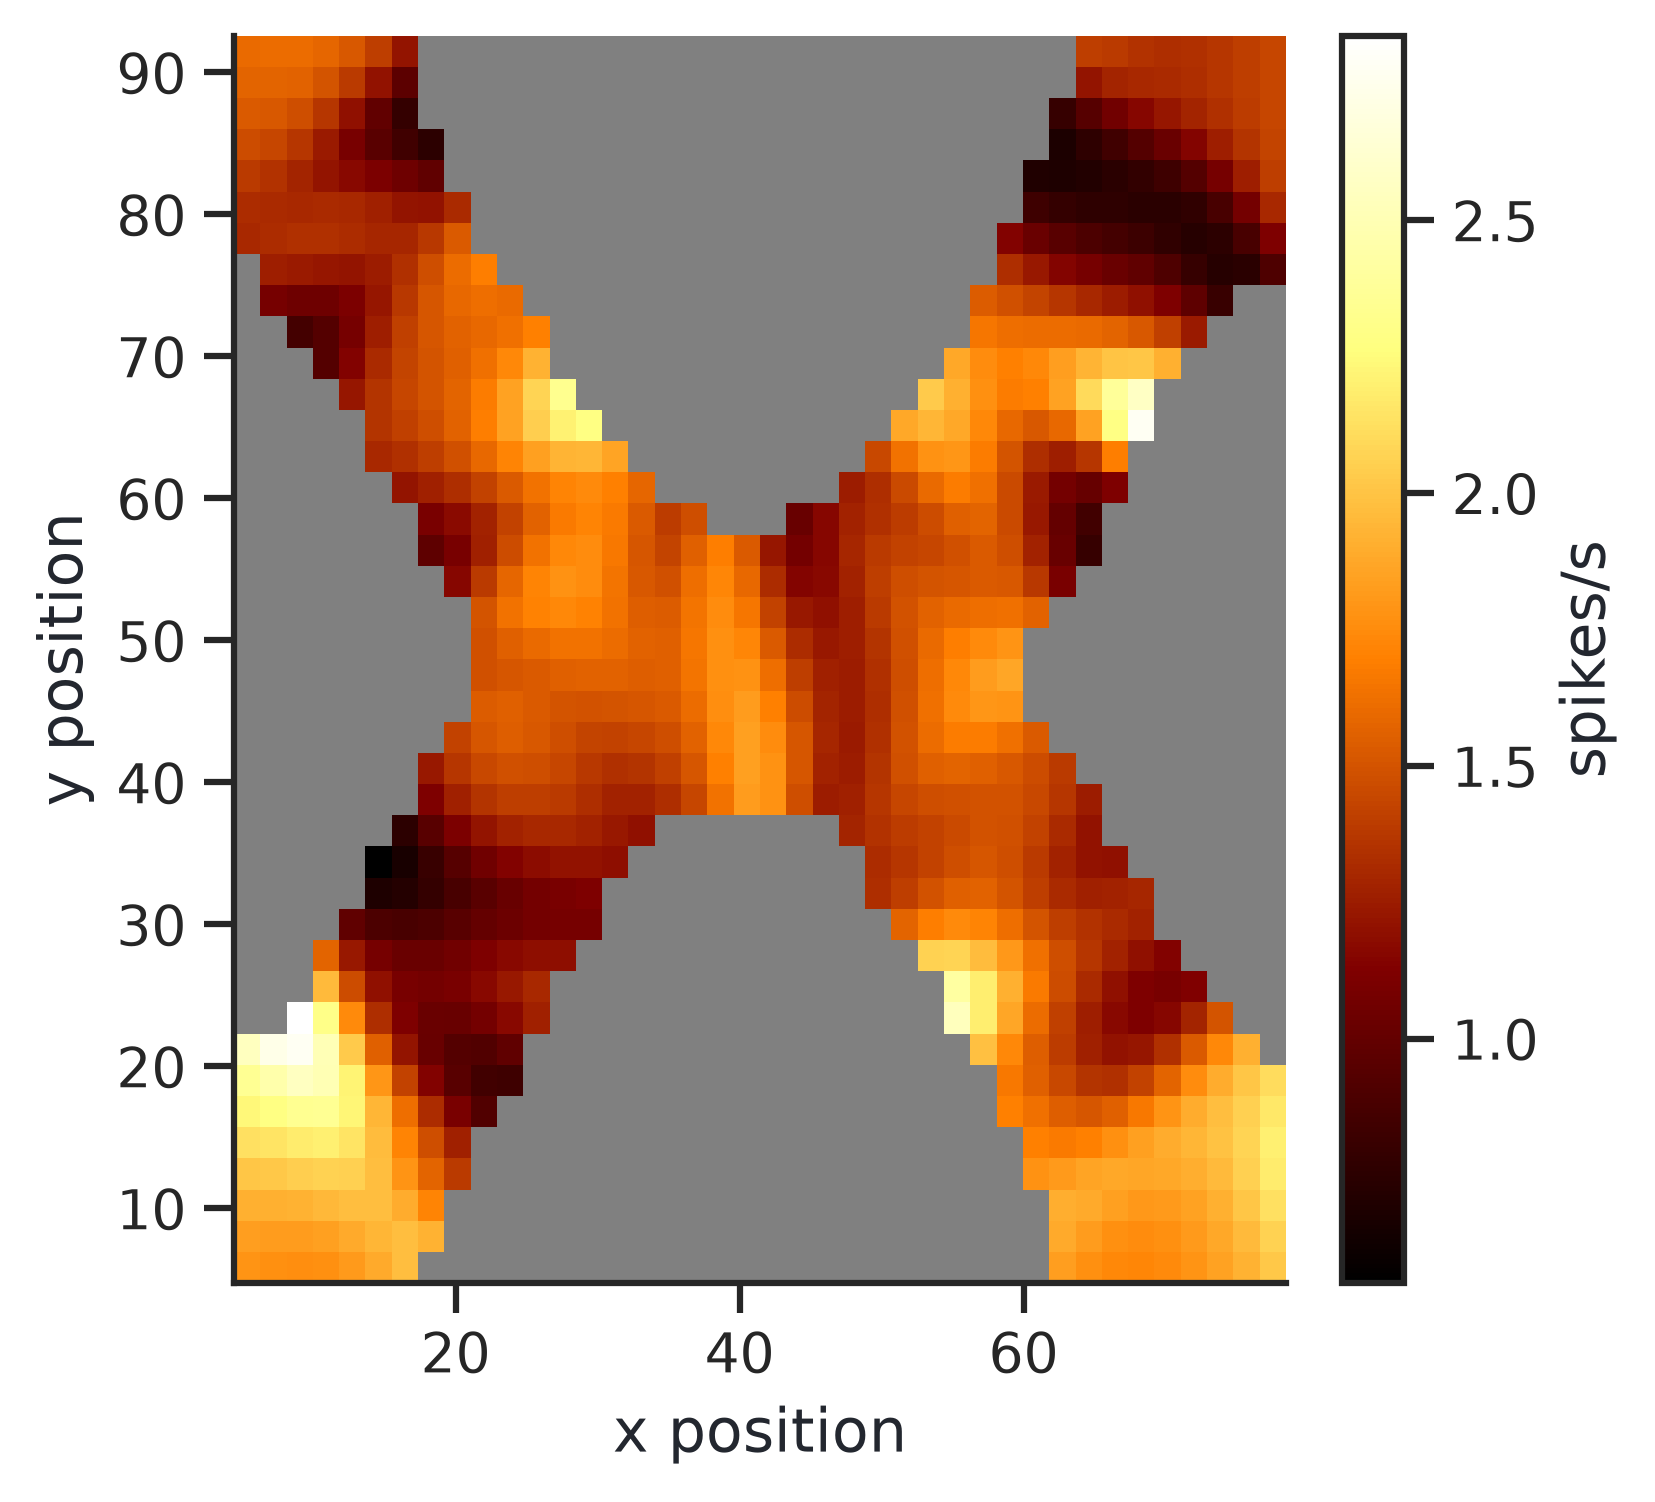

In [91]:
smoothing_sigma = 1.5  # in bins

smoothed_rate_map = smooth_rate_map(
    spike_counts,
    occupancy,
    min_occupancy=min_occupancy,
    smoothing_sigma=smoothing_sigma,
)

fig, ax = plt.subplots(figsize=(5, 4.5))
im = ax.imshow(
    smoothed_rate_map.T,
    origin="lower",
    extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]],
    aspect="equal",
    cmap=RATE_MAP_CMAP,
)
ax.set_xlabel("x position")
ax.set_ylabel("y position")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="spikes/s")
sns.despine(ax=ax)
plt.show()


## 10. Explore Rate Maps Across Units

Now that you have seen how the occupancy map, spike-count map, and rate map fit together, use the cell below to generate the final smoothed rate map for any unit in your filtered CA1 pool.


In [92]:
def plot_final_rate_map(unit_id):
    unit_spike_times = get_unit_spike_times(unit_id)
    unit_spike_times = unit_spike_times[(unit_spike_times >= time[0]) & (unit_spike_times <= time[-1])]

    rate_map_result = compute_rate_map(
        unit_spike_times,
        time,
        x,
        y,
        x_edges,
        y_edges,
        occupancy,
        min_occupancy=min_occupancy,
    )
    smoothed = smooth_rate_map(
        rate_map_result["spike_counts"],
        occupancy,
        min_occupancy=min_occupancy,
        smoothing_sigma=smoothing_sigma,
    )

    fig, ax = plt.subplots(figsize=(4, 4.5))
    im = ax.imshow(
        smoothed.T,
        origin="lower",
        extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]],
        aspect="equal",
        cmap=RATE_MAP_CMAP,
    )
    ax.set_xlabel("x position")
    ax.set_ylabel("y position")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="spikes/s")
    sns.despine(ax=ax)
    plt.show()

    print("unit_id:", unit_id)
    print("firing rate (Hz):", round(candidate_units.loc[unit_id, "firing_rate_hz"], 2))
    print("total spikes in session:", len(unit_spike_times))


final_unit_dropdown = widgets.Dropdown(
    options=list(candidate_units.index),
    value=int(candidate_units.index[0]),
    description="unit_id",
)
widgets.interact(plot_final_rate_map, unit_id=final_unit_dropdown)


interactive(children=(Dropdown(description='unit_id', options=(4, 5, 6, 7, 8, 9, 10, 17, 18, 19, 20, 21, 23, 2…

<function __main__.plot_final_rate_map(unit_id)>

## 11. LFP Preview

Inspect the selected-channel LFP. This file contains LFP from selected channels, not every Neuropixels channel.

In [30]:
lfp_paths = []
for module_name, module in nwb.processing.items():
    if "LFP" in module.data_interfaces:
        lfp_paths.append(module_name)

print("Processing modules with LFP:")
print(lfp_paths)

Processing modules with LFP:
['probe_0_channel_55', 'probe_1_channel_161']


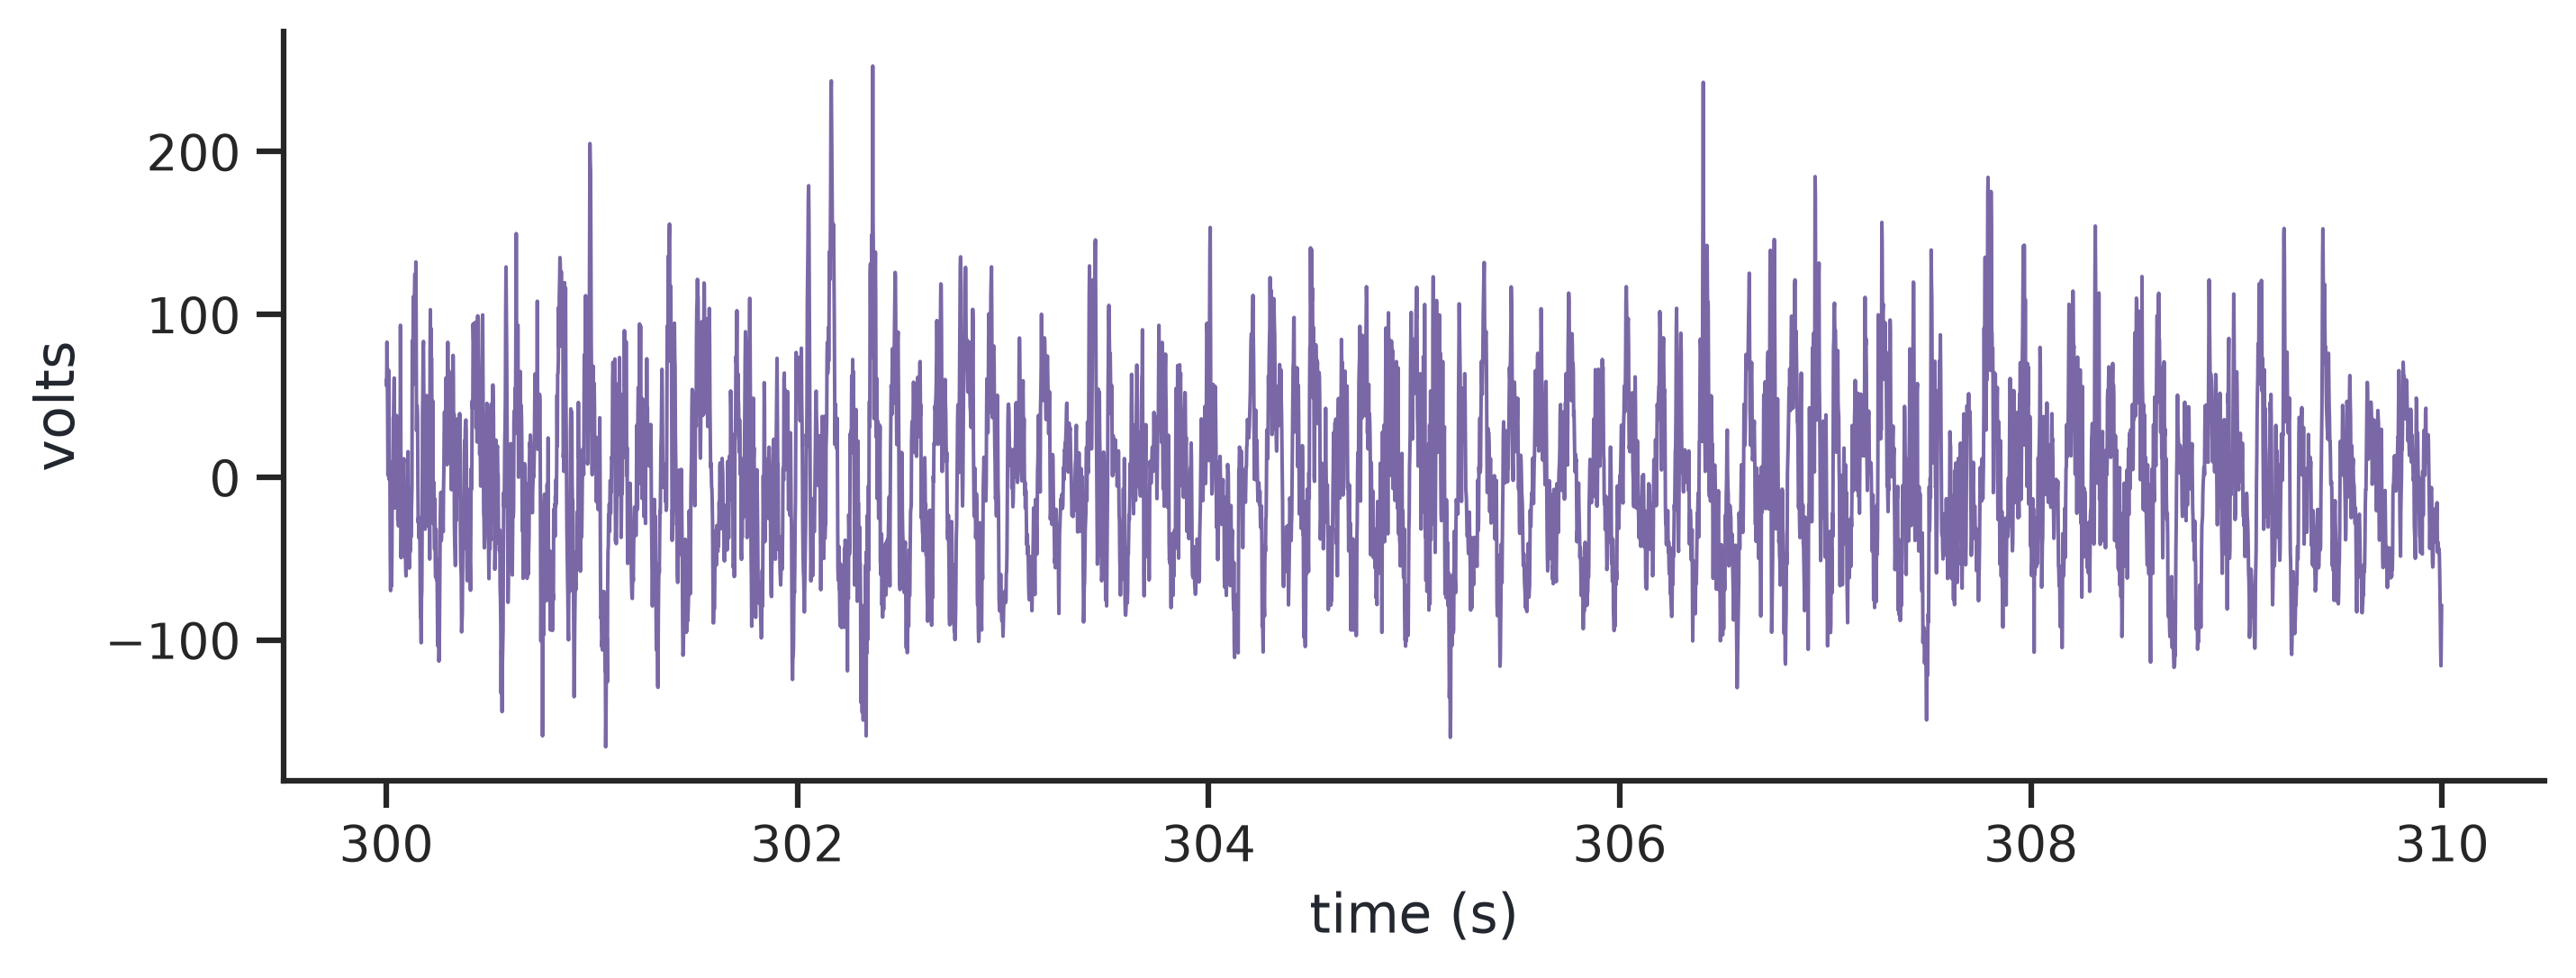

In [31]:
if lfp_paths:
    lfp_module = lfp_paths[0]
    lfp_series = nwb.processing[lfp_module]["LFP"]["LFP"]

    lfp_start_time = 300.0
    lfp_stop_time = 310.0
    lfp_rate = lfp_series.rate
    lfp_start = int((lfp_start_time - lfp_series.starting_time) * lfp_rate)
    lfp_stop = int((lfp_stop_time - lfp_series.starting_time) * lfp_rate)

    lfp_data = np.asarray(lfp_series.data[lfp_start:lfp_stop, 0])
    lfp_time = lfp_series.starting_time + np.arange(lfp_start, lfp_stop) / lfp_rate

    fig, ax = plt.subplots(figsize=(9, 3))
    ax.plot(lfp_time, lfp_data, color=COLORS["purple"], linewidth=0.8)
    ax.set_xlabel("time (s)")
    ax.set_ylabel(lfp_series.unit)
    sns.despine(ax=ax)
    plt.show()
else:
    print("No LFP module found in this file.")